### 🔥 Deep Learning Cave — Chapter 3: The LLaMA's Lair

> *"The old ways were good. The new ways are better."*

The Transformer was revolutionary, but five years of research brought improvements. Welcome to the **LLaMA's Lair** — where we build Meta's state-of-the-art language model with all the modern upgrades.

**Chapter 3** teaches you RoPE, RMSNorm, Grouped Query Attention, and SwiGLU — the techniques that make LLaMA faster, more efficient, and more powerful than the original Transformer.

---

#### 🗺️ Your Position in the Cave

```
[■■■■■■■■■■] Chapter 1: PyTorch Foundations ✓
[■■■■■■■■■■] Chapter 2: The Original Transformer ✓
[■■□□□□□□□□] Chapter 3: Modern LLaMA ← You are here
 ├── RoPE (Rotary Position Embeddings)
 ├── RMSNorm, GQA, SwiGLU
 └── Text generation & sampling

[□□□□□□□□□□] Chapter 4: Vision Transformer
[□□□□□□□□□□] Chapter 5: I-JEPA (Self-Supervised Learning)
```

---

#### 🎯 What is LLaMA?

LLaMA is a family of **large language models** released by Meta AI in February 2023. It represents the state-of-the-art in open-source language modeling and forms the foundation for many popular models like Alpaca, Vicuna, and CodeLlama.

**What LLaMA can do:**
- 📖 **Read and understand** natural language text
- 🔍 **Learn patterns** from massive amounts of training data
- ✍️ **Generate** coherent, human-like text responses
- 🧠 **Reason** about questions and problems
- 💻 **Write code** and explain programming concepts

---

#### 💡 What Makes LLaMA Special? (Key Architectural Innovations)

LLaMA improves upon the original Transformer (2017) with these modern techniques:

| Component | Original Transformer | LLaMA Improvement | Benefit |
|-----------|---------------------|-------------------|---------|
| **Position Encoding** | Sinusoidal (fixed) | **RoPE** (rotary) | Better long-context understanding |
| **Normalization** | LayerNorm (post) | **RMSNorm** (pre) | 10-15% faster, more stable |
| **Attention** | Full MHA | **Grouped Query (GQA)** | 50%+ memory savings |
| **Activation** | ReLU/GELU | **SwiGLU** | Better gradient flow |

---

#### 📚 What You'll Build in This Notebook

By the end, you'll have created a **fully functional LLaMA model** that can generate text! Here's your learning journey:

| Part | What You'll Do | Key Concept |
|------|---------------|-------------|
| **Part 1** | Setup & Imports | PyTorch fundamentals |
| **Part 2** | Model Configuration | Hyperparameters & architecture |
| **Part 3** | Build Components | RoPE, RMSNorm, GQA, SwiGLU |
| **Part 4** | Complete Model | Assembly & forward pass |
| **Part 5** | Data Preparation | Tokenization & batching |
| **Part 6** | Training Loop | Optimization & loss |
| **Part 7** | Text Generation | Sampling strategies |
| **Part 8** | Evaluation & Saving | Perplexity & checkpoints |

---

#### 📖 Key References

- **LLaMA Paper:** Touvron et al., "LLaMA: Open and Efficient Foundation Language Models" (2023)
- **Attention Paper:** Vaswani et al., "Attention Is All You Need" (2017)
- **RoPE Paper:** Su et al., "RoFormer: Enhanced Transformer with Rotary Position Embedding" (2021)

---

**Let's begin building your own language model!** ⬇️

---

### Part 1: Setup and Imports

This section prepares your environment for building the LLaMA model.

---

#### Step 1: Import Required Libraries

🎯 **What it does:** Loads all the Python tools (libraries) we need to build and train our model.

🔧 **Why it matters:** Each library provides essential functionality:

| Library | Purpose | What We Use It For |
|---------|---------|-------------------|
| `torch` | Core deep learning framework | Tensors, automatic differentiation, GPU support |
| `torch.nn` | Neural network building blocks | Layers, activations, loss functions |
| `torch.nn.functional` | Stateless operations | Softmax, attention computations |
| `math` | Mathematical constants/functions | Square root for attention scaling |
| `time` | Timing utilities | Track training duration |
| `Dataset, DataLoader` | Data handling | Batch creation, shuffling |
| `dataclass` | Configuration management | Clean hyperparameter definitions |
| `typing` | Type annotations | Code clarity and IDE support |

💡 **Key insight:** PyTorch uses **dynamic computation graphs**, meaning the network structure can change during runtime. This makes debugging easier compared to static graph frameworks like TensorFlow 1.x.

In [54]:
# Import all required libraries
import math
import time
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from dataclasses import dataclass
from typing import Optional, Tuple
import matplotlib.pyplot as plt
%matplotlib

# Verify imports worked
print("=" * 60)
print("✓ ALL IMPORTS SUCCESSFUL!")
print("=" * 60)
print(f"PyTorch version: {torch.__version__}")
print(f"Python version:  {sys.version.split()[0]}")
print("=" * 60)

Using matplotlib backend: module://matplotlib_inline.backend_inline
✓ ALL IMPORTS SUCCESSFUL!
PyTorch version: 2.6.0
Python version:  3.11.14


#### Step 2: Setup Computing Device

🎯 **What it does:** Detects and configures the best available hardware accelerator for training.

🔧 **Why it matters:** Deep learning involves billions of matrix multiplications. The right hardware can make training:
- **100x faster** on GPU vs CPU
- **Feasible** for larger models that would take days on CPU

**Hardware Options (in order of preference):**

| Device | Speed | Memory | Best For |
|--------|-------|--------|----------|
| **NVIDIA GPU (CUDA)** | ⚡⚡⚡⚡⚡ | 8-80GB | Production training |
| **Apple Silicon (MPS)** | ⚡⚡⚡⚡ | Unified | Mac development |
| **CPU** | ⚡ | System RAM | Small experiments only |

**Why we set a random seed:**
- `torch.manual_seed(42)` ensures **reproducibility**
- Same seed → Same random numbers → Same results every run
- Critical for debugging and scientific comparisons

💡 **Key insight:** Modern GPUs have thousands of cores optimized for parallel matrix operations (tensor cores on NVIDIA). A single RTX 4090 can perform ~80 trillion operations per second!

In [55]:
# Setup device and set random seed for reproducibility
torch.manual_seed(42)

# Detect available hardware
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🍎 Using: Apple Silicon GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"🎮 Using: NVIDIA GPU - {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("💻 Using: CPU (slower, but will work)")

print(f"\nDevice: {device}")

# Test the device with a simple tensor
test = torch.ones(3, 3).to(device)
print(f"\nTest tensor created on {device}:")
print(test)
print("\n✓ Device is working correctly!")

🍎 Using: Apple Silicon GPU (MPS)

Device: mps

Test tensor created on mps:
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]], device='mps:0')

✓ Device is working correctly!


---

### Part 2: Model Configuration

Before building, we define all the settings that control our model's architecture and behavior.

---

#### Step 3: Define Model Settings

🎯 **What it does:** Creates a configuration object (`LLaMAConfig`) that stores all hyperparameters in one place.

🔧 **Why it matters:** Hyperparameters determine:
- **Model capacity:** How much the model can learn
- **Training speed:** How long it takes to train
- **Memory usage:** Whether it fits on your hardware
- **Performance:** How well it generates text

**Key Hyperparameters Explained:**

| Parameter | Our Value | Real LLaMA-7B | What It Controls |
|-----------|-----------|---------------|------------------|
| `vocab_size` | 512 | 32,000 | Number of unique tokens |
| `d_model` | 256 | 4,096 | Width of the model (embedding dimension) |
| `n_layers` | 6 | 32 | Depth of the model (transformer blocks) |
| `n_heads` | 8 | 32 | Parallel attention mechanisms |
| `n_kv_heads` | 4 | 32 | Key/Value heads (GQA) |
| `d_ff` | 1,024 | 11,008 | Feed-forward hidden dimension |
| `max_seq_len` | 128 | 2,048 | Maximum input length |

**Why small values?**
- Fast training on any hardware (minutes, not days)
- Easier to debug and understand
- Same architecture, just scaled down

---

##### 💡 What is `@dataclass`?

It's a Python shortcut that saves you from writing boilerplate code:

```python
# WITHOUT @dataclass - you write all this manually:
class Config:
    def __init__(self, d_model, n_layers, n_heads):
        self.d_model = d_model
        self.n_layers = n_layers
        self.n_heads = n_heads
    
    def __repr__(self):
        return f"Config(d_model={self.d_model}, ...)"

# WITH @dataclass - Python generates __init__ and __repr__ for you:
@dataclass
class Config:
    d_model: int = 256
    n_layers: int = 6
    n_heads: int = 8
```

---

##### 💡 What is `__repr__`?

It controls **how an object looks when you print it**:

```python
# WITHOUT __repr__:
print(config)  # <__main__.Config object at 0x7f8b8c0a1d90>  ← Useless!

# WITH __repr__:
print(config)  # Config(d_model=256, n_layers=6)  ← Actually helpful!
```

The `@dataclass` decorator **generates `__repr__` automatically** so you always get readable output.

---

##### 💡 What is `__post_init__`?

A special method that runs *after* the auto-generated `__init__`. We use it to:
1. **Validate:** Check that `n_heads` divides evenly by `n_kv_heads`
2. **Compute:** Calculate `head_dim = d_model // n_heads`

Think of it as: "After all values are set, do these extra checks and calculations."

In [56]:
# Define model configuration
@dataclass
class LLaMAConfig:
    """All settings for our LLaMA model."""
    
    # Model architecture
    vocab_size: int = 512       # Number of unique characters (updated later)
    d_model: int = 256          # Size of word representations
    n_layers: int = 6           # Number of transformer blocks
    n_heads: int = 8            # Attention heads for Queries
    n_kv_heads: int = 4         # Attention heads for Keys/Values (saves memory!)
    d_ff: int = 1024            # Feed-forward network size
    
    # Training settings
    max_seq_len: int = 128      # Maximum text length
    dropout: float = 0.1        # Regularization (prevents overfitting)
    
    # Technical parameters
    rope_theta: float = 10000.0       # RoPE rotation parameter
    rms_norm_eps: float = 1e-6        # Numerical stability constant
    
    def __post_init__(self):
        """Validate settings."""
        assert self.d_model % self.n_heads == 0
        assert self.n_heads % self.n_kv_heads == 0
        self.head_dim = self.d_model // self.n_heads

# Create configuration
config = LLaMAConfig()

# Display settings
print("MODEL CONFIGURATION")
print("=" * 60)
print(f"Vocabulary size:      {config.vocab_size:>6,} characters")
print(f"Model dimension:      {config.d_model:>6}")
print(f"Number of layers:     {config.n_layers:>6}")
print(f"Attention heads (Q):  {config.n_heads:>6}")
print(f"Attention heads (KV): {config.n_kv_heads:>6}")
print(f"Head dimension:       {config.head_dim:>6}")
print(f"FFN dimension:        {config.d_ff:>6,}")
print(f"Max sequence length:  {config.max_seq_len:>6}")
print("=" * 60)
print("\n💡 These are small values for fast training!")
print("   Real LLaMA uses much bigger numbers.\n")

MODEL CONFIGURATION
Vocabulary size:         512 characters
Model dimension:         256
Number of layers:          6
Attention heads (Q):       8
Attention heads (KV):      4
Head dimension:           32
FFN dimension:         1,024
Max sequence length:     128

💡 These are small values for fast training!
   Real LLaMA uses much bigger numbers.



---

### Part 3: Build Model Components

Now we build each component of LLaMA from scratch. Each section follows the pattern:
1. **Understand the problem** it solves
2. **See the mathematical intuition**
3. **Implement the code**
4. **Verify with examples**

---

#### Step 4: RoPE - Rotary Position Embeddings

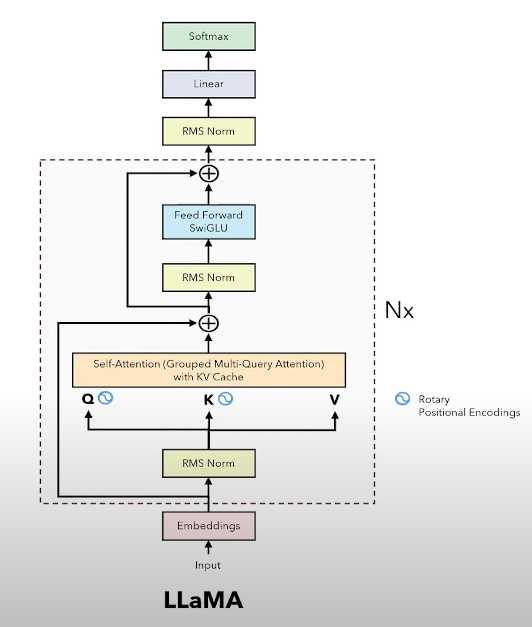

🎯 **What it does:** Encodes the **position** of each token in a sequence using rotations in embedding space.

🔧 **Why it matters:** 

**The Problem:** Neural networks see all inputs simultaneously—they don't naturally know that "Hello" comes before "World". Without position information:
- "The cat sat on the mat" = "mat the on sat cat The" (same to the model!)

**Historical Solutions:**

| Method | How It Works | Limitation |
|--------|--------------|------------|
| **Learned Embeddings** (GPT-2) | Learn a vector for each position | Fixed max length |
| **Sinusoidal** (Original Transformer) | Use sin/cos functions | Doesn't generalize well |
| **Relative Position** (T5) | Encode distance between tokens | Complex implementation |
| **RoPE** (LLaMA) ⭐ | Rotate embeddings based on position | Best of all worlds! |

**How RoPE Works (Intuition):**

Imagine each word as a point in 2D space. RoPE **rotates** each point based on its position:
- Position 0: No rotation (0°)
- Position 1: Small rotation (θ°)
- Position 2: More rotation (2θ°)
- And so on...

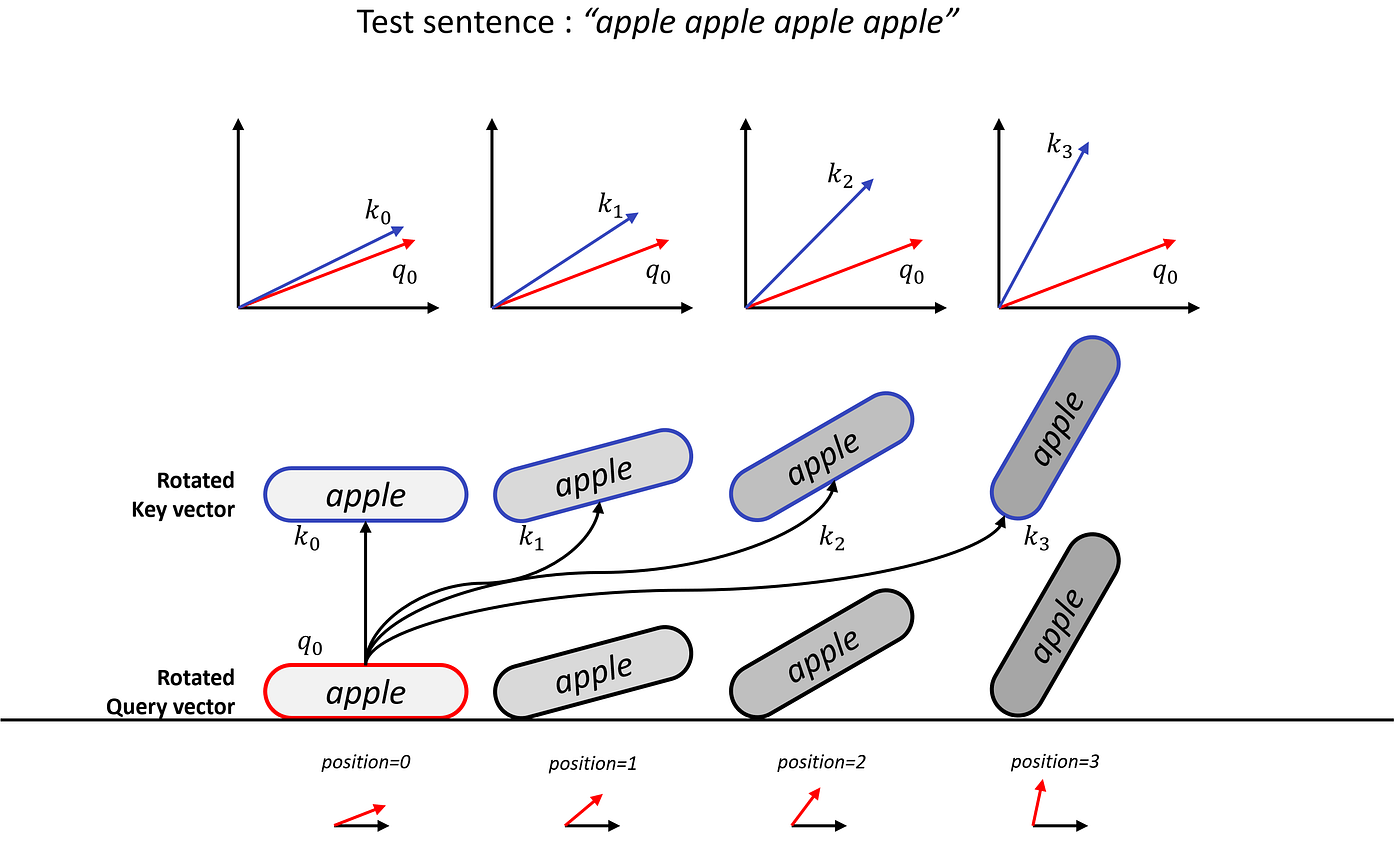

This means:
- **Absolute positions** are encoded (each position has unique rotation)
- **Relative positions** are preserved (distance = difference in rotation)
- **Extrapolates** to longer sequences than seen during training

---

##### The Rotation Matrix (Step by Step)

To rotate a 2D point (x, y) by angle mθ, we use **matrix multiplication**:

```
[cos(mθ)  -sin(mθ)]   [x]
[sin(mθ)   cos(mθ)] × [y]
```

**How to compute it (row × column):**

```
New X = (Row 1) · (Column)
      = cos(mθ) × x  +  (-sin(mθ)) × y
      = x·cos(mθ) - y·sin(mθ)

New Y = (Row 2) · (Column)  
      = sin(mθ) × x  +  cos(mθ) × y
      = x·sin(mθ) + y·cos(mθ)
```

**Concrete Example — Rotate (1, 0) by 90°:**

cos(90°) = 0, sin(90°) = 1

```
New X = 1×0 - 0×1 = 0
New Y = 1×1 + 0×0 = 1

Result: (1, 0) → (0, 1)  ✓ Rotated 90° counterclockwise!
```

**Why RoPE uses this:** Instead of rotating points in 2D space, RoPE rotates **pairs of embedding dimensions**. The angle depends on position `m`:
- Position 0 → mθ = 0 (no rotation)
- Position 1 → mθ = θ (small rotation)
- Position 10 → mθ = 10θ (larger rotation)

This encodes "where am I in the sequence?" directly into the embedding!

---

##### 💻 What We Need to Build

**The Big Picture:**

To rotate embeddings, we need cos and sin values. But computing these during every forward pass is slow. So we **precompute a lookup table**:

```
"For position 0, here are all the cos/sin values you'll need"
"For position 1, here are all the cos/sin values you'll need"
"For position 2, ..."
... and so on
```

**The Intuition:**

Think of it like a recipe book:
1. **Before cooking** → Precompute all the rotation values once
2. **During cooking** → Just look up the values you need

---

##### The Frequency Formula: Why Different Speeds?

Each dimension pair `i` gets a different rotation speed (frequency) using this formula:

```
                    1
frequency[i] = ─────────────
               10000^(2i/d)
```

Or written another way: `freq[i] = 1.0 / (10000 ** (2*i / d))`

Where:
- `d` = head_dim (e.g., 32)
- `i` = dimension pair index (0, 1, 2, ...)

**Let's calculate with d=32:**

| Dimension Pair (i) | Formula | Frequency | Meaning |
|--------------------|---------|-----------|---------|
| i=0 (dims 0,1) | 1/10000^(0/32) = 1/10000^0 | **1.0** | Completes full rotation every ~6 positions |
| i=4 (dims 8,9) | 1/10000^(8/32) = 1/10000^0.25 | **0.1** | Completes rotation every ~63 positions |
| i=8 (dims 16,17) | 1/10000^(16/32) = 1/10000^0.5 | **0.01** | Completes rotation every ~628 positions |
| i=15 (dims 30,31) | 1/10000^(30/32) = 1/10000^0.94 | **0.0002** | Completes rotation every ~31,000 positions |

**Why this formula?**
- **Small i** → exponent near 0 → 10000^0 ≈ 1 → freq = 1/1 = **FAST**
- **Large i** → exponent near 1 → 10000^1 = 10000 → freq = 1/10000 = **SLOW**

**The intuition:** It's like having multiple clocks:
- First dimension pair = **second hand** (fast, tracks nearby words)
- Middle dimension pairs = **minute hand** (medium, tracks phrases)  
- Last dimension pairs = **hour hand** (slow, tracks document structure)

---

##### What Goes Into the Lookup Table?

```
                    Dimension Pairs (different rotation speeds)
                    ┌────────┬────────┬────────┬────────┐
Position 0    →     │ cos,sin│ cos,sin│ cos,sin│  ...   │  ← angle = 0 × freq (no rotation)
Position 1    →     │ cos,sin│ cos,sin│ cos,sin│  ...   │  ← angle = 1 × freq
Position 2    →     │ cos,sin│ cos,sin│ cos,sin│  ...   │  ← angle = 2 × freq
   ...              │  ...   │  ...   │  ...   │  ...   │
Position N    →     │ cos,sin│ cos,sin│ cos,sin│  ...   │  ← angle = N × freq
                    └────────┴────────┴────────┴────────┘
                      i=0       i=4      i=8      i=15
                     freq=1   freq=0.1  freq=0.01 freq=0.0002
                      FAST     MEDIUM    SLOW    VERY SLOW
```

**The angle formula:** `angle[position, i] = position × frequency[i]`

So at position 100:
- Pair 0 (fast): angle = 100 × 1.0 = 100 radians (rotated ~16 full circles!)
- Pair 15 (slow): angle = 100 × 0.0002 = 0.02 radians (barely moved)

💡 **Key insight:** RoPE applies rotations in pairs of dimensions (even/odd indices). Different dimension pairs use different frequencies, creating a rich positional encoding that the model can learn to interpret.

In [57]:
# Create RoPE rotation frequencies
def precompute_rope_freqs(head_dim, max_seq_len, theta=10000.0):
    """
    Precompute rotation frequencies for each position.
    
    Inputs:
        head_dim: Size of each attention head (e.g., 32)
        max_seq_len: Max sequence length (e.g., 128)
        theta: Rotation speed control (default: 10000)
    
    Returns:
        Tensor with cos/sin values for each position
    """
    # Calculate frequencies
    freqs = 1.0 / (theta ** (torch.arange(0, head_dim, 2).float() / head_dim))
    
    # Position indices: 0, 1, 2, ..., max_seq_len-1
    positions = torch.arange(max_seq_len).float()
    
    # Outer product: position × frequency
    freqs = torch.outer(positions, freqs)
    
    # Convert to cos and sin (for rotation)
    freqs_cos = torch.cos(freqs)
    freqs_sin = torch.sin(freqs)
    
    return torch.stack([freqs_cos, freqs_sin], dim=-1)

# Example usage
print("EXAMPLE: Creating RoPE Frequencies")
print("=" * 60)
rope_freqs = precompute_rope_freqs(head_dim=32, max_seq_len=10)
print(f"Input:  head_dim=32, max_seq_len=10")
print(f"Output: shape {rope_freqs.shape}")
print(f"        (10 positions, 16 freq pairs, 2 values [cos,sin])")
print(f"\nPosition 0 (first 3 frequency pairs):")
print(rope_freqs[0, :3])
print(f"\nPosition 5 (first 3 frequency pairs):")
print(rope_freqs[5, :3])
print("\n✓ Each position has unique rotation values!")

EXAMPLE: Creating RoPE Frequencies
Input:  head_dim=32, max_seq_len=10
Output: shape torch.Size([10, 16, 2])
        (10 positions, 16 freq pairs, 2 values [cos,sin])

Position 0 (first 3 frequency pairs):
tensor([[1., 0.],
        [1., 0.],
        [1., 0.]])

Position 5 (first 3 frequency pairs):
tensor([[ 0.2837, -0.9589],
        [-0.9461,  0.3239],
        [-0.0103,  0.9999]])

✓ Each position has unique rotation values!


In [58]:
# Apply RoPE rotations to data
def apply_rope(x, freqs):
    """
    Apply rotations to word representations.
    
    Inputs:
        x: Tensor (batch, n_heads, seq_len, head_dim)
        freqs: Precomputed rotation values
    
    Returns:
        Rotated tensor (same shape as input)
    """
    batch, n_heads, seq_len, head_dim = x.shape
    
    # Separate even/odd dimensions
    x_reshaped = x.reshape(batch, n_heads, seq_len, head_dim // 2, 2)
    x_even = x_reshaped[..., 0]  # Elements at indices 0, 2, 4, ...
    x_odd = x_reshaped[..., 1]   # Elements at indices 1, 3, 5, ...
    
    # Get cos/sin values
    cos = freqs[:seq_len, :, 0].unsqueeze(0).unsqueeze(0)
    sin = freqs[:seq_len, :, 1].unsqueeze(0).unsqueeze(0)
    
    # Apply 2D rotation
    rotated_even = x_even * cos - x_odd * sin
    rotated_odd = x_even * sin + x_odd * cos
    
    # Combine back
    rotated = torch.stack([rotated_even, rotated_odd], dim=-1)
    return rotated.reshape(batch, n_heads, seq_len, head_dim)

# Test RoPE
print("\nEXAMPLE: Applying RoPE")
print("=" * 60)
test_data = torch.randn(2, 4, 10, 32)
print(f"Input:  {test_data.shape}")
print(f"        (2 sentences, 4 heads, 10 words, 32 dimensions)")

rotated = apply_rope(test_data, rope_freqs)
print(f"\nOutput: {rotated.shape}")
print(f"        (same shape, but values rotated based on position)")
print(f"\nChanged: {not torch.equal(test_data, rotated)}")
print("\n✓ RoPE applied! Model now knows word positions.")


EXAMPLE: Applying RoPE
Input:  torch.Size([2, 4, 10, 32])
        (2 sentences, 4 heads, 10 words, 32 dimensions)

Output: torch.Size([2, 4, 10, 32])
        (same shape, but values rotated based on position)

Changed: True

✓ RoPE applied! Model now knows word positions.


#### 🔬 Deep Dive: RoPE Rotation Mathematics

Let's understand exactly how RoPE rotates embeddings at the mathematical level.

---

##### The 2D Rotation Matrix

In 2D space, rotating a point $(x, y)$ by angle $\theta$ uses this matrix:

$$R(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}$$

**Visual ASCII Representation:**

```
        y
        │      • (x', y') ← Rotated point
        │    ╱
        │  ╱  θ (rotation angle)
        │╱────────• (x, y) ← Original point
        └──────────────── x
```

After rotation:
- $x' = x \cdot \cos\theta - y \cdot \sin\theta$
- $y' = x \cdot \sin\theta + y \cdot \cos\theta$

---

##### How RoPE Applies Rotations to Embeddings

RoPE treats **pairs of dimensions** as 2D planes and rotates them:

```
Embedding Vector: [d₀, d₁, d₂, d₃, d₄, d₅, d₆, d₇, ...]
                   └─┬─┘  └─┬─┘  └─┬─┘  └─┬─┘
                  Rotate  Rotate  Rotate  Rotate
                  by θ₀   by θ₁   by θ₂   by θ₃
                  
Position 0: θ = 0 (no rotation)
Position 1: θ = base_frequency
Position m: θ = m × base_frequency
```

Each dimension pair uses a **different frequency**, creating a rich positional encoding!

##### Why θ_base = 10,000? (Frequency Bands)

The base theta creates a **spectrum of frequencies**:

$$\theta_i = \frac{1}{10000^{2i/d}}$$

| Dimension Pair | Frequency | Period | What It Captures |
|----------------|-----------|--------|------------------|
| 0-1 | 1.0 | ~6 positions | Adjacent tokens (local syntax) |
| 8-9 | 0.1 | ~63 positions | Phrase-level patterns |
| 16-17 | 0.01 | ~628 positions | Paragraph structure |
| 30-31 | 0.0001 | ~62,832 positions | Document-level (global) |

**Intuition:** Like a clock with multiple hands—second hand (fast) for fine timing, hour hand (slow) for coarse timing. The model learns which "hands" matter for different tasks!

---

##### RoPE vs Other Position Encodings

| Method | Max Length | Extrapolation | Relative Position |
|--------|------------|---------------|-------------------|
| **Learned** (GPT-2) | Fixed (512-2048) | ❌ Poor | ❌ No |
| **Sinusoidal** (Transformer) | Unlimited | ⚠️ Moderate | ❌ No |
| **ALiBi** (BLOOM) | Unlimited | ✅ Good | ✅ Yes |
| **RoPE** (LLaMA) ⭐ | Unlimited | ✅ Good | ✅ Yes |

---

##### 💡 Why RoPE Wins: The Key Mathematical Insight

**The Problem with Other Methods:**

| Method | Issue |
|--------|-------|
| **Learned Embeddings** | Position 513 is unknown if trained on max 512 → model sees garbage |
| **Sinusoidal** | Absolute positions encoded, but distance 5↔10 looks different than 105↔110! |

**Why RoPE Solves This:**

When computing attention between Query at position `m` and Key at position `n`:

$$Q_m \cdot K_n = f(q, k, \textbf{m-n})$$

The dot product **only depends on relative distance (m-n)**, not absolute positions!

```
Position 5 attending to Position 3:   rotation difference = 2θ
Position 100 attending to Position 98: rotation difference = 2θ
                                        ↑ SAME attention pattern!
```

**This gives RoPE three superpowers:**

| Benefit | Explanation |
|---------|-------------|
| **Generalization** | Pattern learned at positions 5↔3 automatically works at 100↔98 |
| **Extrapolation** | Can handle longer sequences than seen during training |
| **Efficiency** | No extra parameters needed (unlike learned embeddings) |

RoPE naturally encodes **relative distance**: when computing attention between positions $m$ and $n$, the rotation difference depends only on $m-n$!

In [59]:
# 🔬 RoPE Deep Dive: Step-by-Step Rotation Demo
print("=" * 65)
print("🔬 ROPE DEEP DIVE: Tracing Rotation Step-by-Step")
print("=" * 65)

# Use small dimensions for clarity
demo_head_dim = 4
demo_seq_len = 3
demo_theta = 10.0  # Smaller theta for visible rotation

print("\n1️⃣ Computing frequency for each dimension pair:")
print("-" * 55)
dim_indices = torch.arange(0, demo_head_dim, 2).float()
frequencies = 1.0 / (demo_theta ** (dim_indices / demo_head_dim))
print(f"   Dimension pair 0 (dims 0,1): freq = {frequencies[0]:.4f} (rotates FAST)")
print(f"   Dimension pair 1 (dims 2,3): freq = {frequencies[1]:.4f} (rotates SLOWER)")

print("\n2️⃣ Computing rotation angles for each position:")
print("-" * 55)
for pos in range(demo_seq_len):
    angles = pos * frequencies
    print(f"   Position {pos}: angles = [{angles[0]:.4f}, {angles[1]:.4f}] radians")
    print(f"              = [{math.degrees(angles[0]):.1f}°, {math.degrees(angles[1]):.1f}°]")

print("\n3️⃣ Applying rotation to a sample embedding [1, 0, 1, 0]:")
print("-" * 55)
sample_emb = torch.tensor([[1.0, 0.0], [1.0, 0.0]])  # Two pairs, each = [1, 0]

for pos in range(demo_seq_len):
    angles = pos * frequencies
    cos_a, sin_a = torch.cos(angles), torch.sin(angles)
    # Apply 2D rotation: [x', y'] = [x*cos - y*sin, x*sin + y*cos]
    rotated_x = sample_emb[:, 0] * cos_a - sample_emb[:, 1] * sin_a
    rotated_y = sample_emb[:, 0] * sin_a + sample_emb[:, 1] * cos_a
    result = torch.stack([rotated_x, rotated_y], dim=1).flatten()
    print(f"   Position {pos}: [1,0,1,0] → [{result[0]:.3f}, {result[1]:.3f}, {result[2]:.3f}, {result[3]:.3f}]")

print("\n4️⃣ Key Insight - Relative position is preserved:")
print("-" * 55)
print("   When Q at pos 5 attends to K at pos 3:")
print("   Q·K depends on rotation(5) - rotation(3) = rotation(2)")
print("   → Same as Q at pos 7 attending to K at pos 5!")
print("\n✅ RoPE encodes BOTH absolute AND relative positions!")

🔬 ROPE DEEP DIVE: Tracing Rotation Step-by-Step

1️⃣ Computing frequency for each dimension pair:
-------------------------------------------------------
   Dimension pair 0 (dims 0,1): freq = 1.0000 (rotates FAST)
   Dimension pair 1 (dims 2,3): freq = 0.3162 (rotates SLOWER)

2️⃣ Computing rotation angles for each position:
-------------------------------------------------------
   Position 0: angles = [0.0000, 0.0000] radians
              = [0.0°, 0.0°]
   Position 1: angles = [1.0000, 0.3162] radians
              = [57.3°, 18.1°]
   Position 2: angles = [2.0000, 0.6325] radians
              = [114.6°, 36.2°]

3️⃣ Applying rotation to a sample embedding [1, 0, 1, 0]:
-------------------------------------------------------
   Position 0: [1,0,1,0] → [1.000, 0.000, 1.000, 0.000]
   Position 1: [1,0,1,0] → [0.540, 0.841, 0.950, 0.311]
   Position 2: [1,0,1,0] → [-0.416, 0.909, 0.807, 0.591]

4️⃣ Key Insight - Relative position is preserved:
------------------------------------------

#### Step 5: RMSNorm - Root Mean Square Normalization

🎯 **What it does:** Normalizes activations by dividing by their root-mean-square value, keeping the scale consistent throughout the network.

🔧 **Why it matters:**

**The Problem (Internal Covariate Shift):**
During training, the distribution of layer inputs changes as previous layers update. This causes:
- Unstable gradients (too big or too small)
- Slow convergence
- Training can diverge completely!

**Evolution of Normalization:**

| Method | Formula | Speed | Quality |
|--------|---------|-------|---------|
| **BatchNorm** (2015) | Normalize across batch | Fast | Batch-dependent |
| **LayerNorm** (2016) | Normalize across features | Medium | Good |
| **RMSNorm** (2019) ⭐ | RMS normalization only | **Fastest** | **Equal or better** |

**How RMSNorm Differs from LayerNorm:**

```
LayerNorm: y = (x - mean(x)) / std(x) * γ + β   (4 operations)
RMSNorm:   y = x / RMS(x) * γ                    (2 operations)
```

RMSNorm **skips the mean-centering step** because:
1. Research showed re-centering isn't necessary for transformers
2. Removing it gives 10-15% speedup
3. Performance is the same or better

**Mathematical Definition:**

$$\text{RMS}(x) = \sqrt{\frac{1}{d} \sum_{i=1}^{d} x_i^2}$$

$$\text{RMSNorm}(x) = \frac{x}{\text{RMS}(x)} \cdot \gamma$$

Where:
- $d$ = dimension size
- $\gamma$ = learnable scale parameter
- $\epsilon$ = small constant for numerical stability (prevent division by zero)

**Pre-Norm vs Post-Norm:**

LLaMA uses **Pre-Normalization** (normalize BEFORE each sub-layer):
```
Pre-Norm:  output = x + SubLayer(Norm(x))   ← LLaMA uses this
Post-Norm: output = Norm(x + SubLayer(x))   ← Original Transformer
```

Pre-norm is more stable for deep networks and doesn't require learning rate warmup.

💡 **Key insight:** The learnable parameter `γ` (gamma) allows the model to adjust the scale after normalization. Initially set to 1.0, it learns the optimal scale during training.

In [60]:
# RMSNorm implementation
class RMSNorm(nn.Module):
    """Root Mean Square Normalization."""
    
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps  # Prevent division by zero
        self.weight = nn.Parameter(torch.ones(dim))  # Learnable scale
    
    def forward(self, x):
        """
        Normalize input.
        
        Input:  x with shape (..., dim)
        Output: Normalized x (same shape)
        """
        # Calculate RMS: sqrt(mean(x²))
        rms = torch.sqrt(torch.mean(x ** 2, dim=-1, keepdim=True) + self.eps)
        # Normalize and scale
        return self.weight * (x / rms)

# Example usage
print("EXAMPLE: Using RMSNorm")
print("=" * 60)

rms_norm = RMSNorm(dim=8)
test_input = torch.randn(2, 5, 8)  # 2 sentences, 5 words, 8 dims

print("BEFORE RMSNorm:")
print(f"  Shape: {test_input.shape}")
print(f"  First word values: {test_input[0, 0, :4]}")
print(f"  Mean: {test_input[0, 0].mean():.4f}")
print(f"  Std:  {test_input[0, 0].std():.4f}")

output = rms_norm(test_input)

print("\nAFTER RMSNorm:")
print(f"  Shape: {output.shape}")
print(f"  First word values: {output[0, 0, :4]}")
print(f"  RMS (should be ~1.0): {torch.sqrt((output[0, 0]**2).mean()):.4f}")
print("\n✓ Numbers are now balanced and stable!")

EXAMPLE: Using RMSNorm
BEFORE RMSNorm:
  Shape: torch.Size([2, 5, 8])
  First word values: tensor([-0.6744, -1.8893, -1.8424,  0.1323])
  Mean: -0.2445
  Std:  1.3287

AFTER RMSNorm:
  Shape: torch.Size([2, 5, 8])
  First word values: tensor([-0.5324, -1.4915, -1.4545,  0.1044], grad_fn=<SliceBackward0>)
  RMS (should be ~1.0): 1.0000

✓ Numbers are now balanced and stable!


#### Step 6: Grouped Query Attention (GQA)

🎯 **What it does:** A memory-efficient variant of multi-head attention that shares Key and Value projections across multiple Query heads.

🔧 **Why it matters:**

**The Attention Mechanism (Quick Review):**

Attention answers: "For each word, which other words should I pay attention to?"

It computes:
```
Attention(Q, K, V) = softmax(Q·Kᵀ / √d) · V
```

Where:
- **Q (Query):** "What am I looking for?"
- **K (Key):** "What do I contain?"
- **V (Value):** "What information do I have?"

**Multi-Head Attention (MHA):**
Instead of one attention, we use multiple "heads" that can focus on different aspects:
- Head 1 might focus on syntax
- Head 2 might focus on semantics
- Head 3 might focus on coreference
- etc.

**The Memory Problem:**

For each head, we store Q, K, V matrices. During inference with KV-caching:
```
Memory = batch_size × seq_len × n_heads × head_dim × 2 (K and V)
```

For LLaMA-65B with 2048 tokens: **~40GB just for KV cache!**

**The GQA Solution:**

| Method | Q Heads | KV Heads | KV Memory | Quality |
|--------|---------|----------|-----------|---------|
| **MHA** (Original) | 8 | 8 | 100% | Baseline |
| **MQA** (Multi-Query) | 8 | 1 | 12.5% | Slightly worse |
| **GQA** (Grouped) ⭐ | 8 | 4 | 50% | **Same as MHA!** |

**How GQA Works:**

```
Standard MHA:
Q₁ ↔ K₁,V₁    Q₂ ↔ K₂,V₂    Q₃ ↔ K₃,V₃    Q₄ ↔ K₄,V₄
Q₅ ↔ K₅,V₅    Q₆ ↔ K₆,V₆    Q₇ ↔ K₇,V₇    Q₈ ↔ K₈,V₈

GQA (groups of 2):
Q₁,Q₂ ↔ K₁,V₁    Q₃,Q₄ ↔ K₂,V₂    Q₅,Q₆ ↔ K₃,V₃    Q₇,Q₈ ↔ K₄,V₄
```

Each K/V pair serves multiple Q heads by **repeating** (broadcasting) them.

**The Attention Formula:**

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

The $\sqrt{d_k}$ scaling prevents the dot products from becoming too large, which would push softmax into regions with tiny gradients.

**Causal Masking:**

For language modeling, we prevent tokens from "seeing the future":
```
Mask = [[1, 0, 0, 0],
        [1, 1, 0, 0],
        [1, 1, 1, 0],
        [1, 1, 1, 1]]
```
Position 2 can only attend to positions 0, 1, 2 (not 3).

💡 **Key insight:** GQA achieves the "sweet spot" between memory efficiency and model quality. Research showed that with enough training, GQA matches full MHA performance while using 50% less memory.

In [61]:
# Grouped Query Attention
class GroupedQueryAttention(nn.Module):
    """Memory-efficient attention with shared K/V heads."""
    
    def __init__(self, config):
        super().__init__()
        self.n_heads = config.n_heads        # Query heads (8)
        self.n_kv_heads = config.n_kv_heads  # K/V heads (4)
        self.head_dim = config.head_dim
        self.d_model = config.d_model
        
        # How many Q heads per K/V head?
        self.n_rep = self.n_heads // self.n_kv_heads
        
        # Projection layers (note: K/V have fewer heads!)
        self.wq = nn.Linear(self.d_model, self.n_heads * self.head_dim, bias=False)
        self.wk = nn.Linear(self.d_model, self.n_kv_heads * self.head_dim, bias=False)
        self.wv = nn.Linear(self.d_model, self.n_kv_heads * self.head_dim, bias=False)
        self.wo = nn.Linear(self.n_heads * self.head_dim, self.d_model, bias=False)
        
        self.dropout = nn.Dropout(config.dropout)
        
        # Store RoPE frequencies
        self.register_buffer(
            "rope_freqs",
            precompute_rope_freqs(self.head_dim, config.max_seq_len, config.rope_theta)
        )
    
    def forward(self, x, mask=None, return_attn=False):
        """Apply grouped query attention."""
        batch_size, seq_len, _ = x.shape
        
        # Project to Q, K, V
        q = self.wq(x).view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.wk(x).view(batch_size, seq_len, self.n_kv_heads, self.head_dim).transpose(1, 2)
        v = self.wv(x).view(batch_size, seq_len, self.n_kv_heads, self.head_dim).transpose(1, 2)
        
        # Apply RoPE
        q = apply_rope(q, self.rope_freqs)
        k = apply_rope(k, self.rope_freqs)
        
        # Repeat K/V to match Q heads
        if self.n_rep > 1:
            k = k.repeat_interleave(self.n_rep, dim=1)
            v = v.repeat_interleave(self.n_rep, dim=1)
        
        # Calculate attention
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights_dropped = self.dropout(attn_weights)
        
        # Apply to values and combine heads
        output = torch.matmul(attn_weights_dropped, v)
        output = output.transpose(1, 2).contiguous().view(batch_size, seq_len, -1)
        
        if return_attn:
            return self.wo(output), attn_weights  # Return pre-dropout weights
        return self.wo(output)

# Test Grouped Query Attention
print("EXAMPLE: Testing Grouped Query Attention")
print("=" * 60)

gqa = GroupedQueryAttention(config).to(device)
test_x = torch.randn(2, 10, config.d_model).to(device)

print(f"Input: {test_x.shape}")
print(f"       (2 sentences, 10 words, {config.d_model} dimensions)")

# Create causal mask (prevent looking at future words)
causal_mask = torch.tril(torch.ones(10, 10)).unsqueeze(0).unsqueeze(0).to(device)
print(f"\nCausal mask: {causal_mask.shape}")
print(f"First 5x5 of mask:\n{causal_mask[0, 0, :5, :5].int()}")
print("(1 = can attend, 0 = cannot attend)")

output = gqa(test_x, mask=causal_mask)

print(f"\nOutput: {output.shape}")
print(f"\nMemory Savings:")
print(f"  Query heads:     {gqa.n_heads}")
print(f"  Key/Value heads: {gqa.n_kv_heads}")
print(f"  Savings:         {(1 - gqa.n_kv_heads/gqa.n_heads)*100:.0f}%")
print("\n✓ Grouped Query Attention working!")

EXAMPLE: Testing Grouped Query Attention
Input: torch.Size([2, 10, 256])
       (2 sentences, 10 words, 256 dimensions)

Causal mask: torch.Size([1, 1, 10, 10])
First 5x5 of mask:
tensor([[1, 0, 0, 0, 0],
        [1, 1, 0, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1]], device='mps:0', dtype=torch.int32)
(1 = can attend, 0 = cannot attend)

Output: torch.Size([2, 10, 256])

Memory Savings:
  Query heads:     8
  Key/Value heads: 4
  Savings:         50%

✓ Grouped Query Attention working!


#### 🔬 Deep Dive: GQA Memory Analysis

Let's calculate exactly how much memory GQA saves with real numbers.

---

##### Concrete Memory Calculation

For a model generating text with KV-caching:
- **Batch size:** 1
- **Sequence length:** 2,048 tokens
- **Heads:** 32
- **Head dimension:** 128
- **Data type:** FP16 (2 bytes)

**Full Multi-Head Attention (MHA):**
```
K-cache per layer = seq × heads × head_dim × bytes
                  = 2048 × 32 × 128 × 2 = 16.8 MB
V-cache per layer = 16.8 MB
Total per layer   = 33.6 MB
For 32 layers     = 33.6 × 32 = 1,075 MB ≈ 1 GB
```

**Grouped Query Attention (8 KV heads):**
```
K-cache per layer = 2048 × 8 × 128 × 2 = 4.2 MB
V-cache per layer = 4.2 MB
Total per layer   = 8.4 MB
For 32 layers     = 8.4 × 32 = 269 MB

Memory Savings = 75%! 🎉
```

---

##### Head Grouping Visualization

```
┌─────────────────────────────────────────────────────────┐
│ MULTI-HEAD ATTENTION (MHA): Each Q has dedicated K,V   │
│                                                         │
│   Q₀ → K₀,V₀    Q₁ → K₁,V₁    Q₂ → K₂,V₂    Q₃ → K₃,V₃│
│   Q₄ → K₄,V₄    Q₅ → K₅,V₅    Q₆ → K₆,V₆    Q₇ → K₇,V₇│
│                                                         │
│   Total K,V pairs: 8 (same as Q heads)                  │
├─────────────────────────────────────────────────────────┤
│ GROUPED QUERY ATTENTION (GQA): Queries SHARE K,V       │
│                                                         │
│   Q₀ ─┐           Q₂ ─┐           Q₄ ─┐           Q₆ ─┐│
│       ├→ K₀,V₀        ├→ K₁,V₁        ├→ K₂,V₂        ├→ K₃,V₃│
│   Q₁ ─┘           Q₃ ─┘           Q₅ ─┘           Q₇ ─┘│
│                                                         │
│   Total K,V pairs: 4 (fewer than Q heads!)              │
├─────────────────────────────────────────────────────────┤
│ MULTI-QUERY ATTENTION (MQA): ALL queries share ONE K,V │
│                                                         │
│   Q₀ ─┐                                                 │
│   Q₁ ─┤                                                 │
│   Q₂ ─┼──────────→ K₀,V₀                                │
│   ... │                                                 │
│   Q₇ ─┘                                                 │
│                                                         │
│   Total K,V pairs: 1 (maximum sharing)                  │
└─────────────────────────────────────────────────────────┘
```

#### 🔬 Deep Dive: KV-Caching for Fast Inference

KV-caching is **critical** for efficient text generation. Here's why:

---

##### The Problem: Redundant Computation

Without caching, generating each new token recomputes ALL previous K,V:

```
Generate token 1: Compute K,V for [tok₁]           → 1 computation
Generate token 2: Compute K,V for [tok₁, tok₂]     → 2 computations  
Generate token 3: Compute K,V for [tok₁, tok₂, tok₃] → 3 computations
...
Generate token N: Compute K,V for [tok₁...tokₙ]    → N computations

Total = 1 + 2 + 3 + ... + N = N(N+1)/2 = O(N²) 🐌
```

##### The Solution: Cache and Reuse

With KV-cache, we store previous computations:

```
Generate token 1: Compute K₁,V₁, cache them        → 1 computation
Generate token 2: Compute K₂,V₂, concat to cache   → 1 computation
Generate token 3: Compute K₃,V₃, concat to cache   → 1 computation
...
Generate token N: Compute Kₙ,Vₙ, concat to cache   → 1 computation

Total = N computations = O(N) 🚀
```

---

##### Cache Growth During Generation

```
Step:     1      2      3      4      5      6
          │      │      │      │      │      │
Cache:   [K₁]  [K₁K₂] [K₁K₂K₃] ...
         [V₁]  [V₁V₂] [V₁V₂V₃] ...
          │      │      │      │      │      │
Size:    ▓     ▓▓    ▓▓▓   ▓▓▓▓  ▓▓▓▓▓ ▓▓▓▓▓▓
          └─────────────────────────────────────┘
                   Linear growth in memory
```

**Trade-off:** O(N) memory for O(N) compute (instead of O(N²) compute)

In [62]:
# 🔬 GQA & KV-Cache Deep Dive Demo
print("=" * 65)
print("🔬 GQA & KV-CACHE DEEP DIVE")
print("=" * 65)

def compute_kv_memory_mb(seq_len, n_kv_heads, head_dim, n_layers, dtype_bytes=2):
    """Calculate KV cache memory in megabytes."""
    k_size = seq_len * n_kv_heads * head_dim * dtype_bytes
    v_size = k_size
    total = (k_size + v_size) * n_layers
    return total / (1024 * 1024)

print("\n1️⃣ Memory comparison for different attention types:")
print("-" * 60)

seq_len, head_dim, n_layers = 2048, 128, 32

model_configs = [
    ("Full MHA (32 KV heads)", 32),
    ("GQA-8 (8 KV heads)", 8),
    ("GQA-4 (4 KV heads)", 4),
    ("MQA (1 KV head)", 1),
]

baseline = compute_kv_memory_mb(seq_len, 32, head_dim, n_layers)
print(f"{'Configuration':<25} {'Memory (MB)':<15} {'Savings':<10}")
print("-" * 60)
for name, kv_heads in model_configs:
    mem = compute_kv_memory_mb(seq_len, kv_heads, head_dim, n_layers)
    savings = (1 - mem / baseline) * 100
    print(f"{name:<25} {mem:<15.1f} {savings:.0f}%")

print("\n2️⃣ Demonstrating repeat_interleave (how GQA broadcasts K,V):")
print("-" * 60)
# Simulate 4 KV heads being expanded to 8 Q heads
kv_heads_demo = torch.tensor([[1], [2], [3], [4]])  # 4 KV heads
print(f"Original KV heads (4 heads): {kv_heads_demo.flatten().tolist()}")
expanded = kv_heads_demo.repeat_interleave(2, dim=0)  # Expand to 8
print(f"After repeat_interleave(2):  {expanded.flatten().tolist()}")
print("Each KV head now serves 2 Q heads!")

print("\n3️⃣ Simulating KV-cache during generation:")
print("-" * 60)

class SimpleKVCache:
    def __init__(self):
        self.keys = []
        self.values = []
    
    def add_token(self, k, v):
        self.keys.append(k)
        self.values.append(v)
    
    def get_cached(self):
        if not self.keys:
            return None, None
        return torch.stack(self.keys), torch.stack(self.values)

cache = SimpleKVCache()
print("Generating 5 tokens with caching...")
for i in range(5):
    new_k = torch.randn(4, 32)  # 4 heads, 32 dim
    new_v = torch.randn(4, 32)
    cache.add_token(new_k, new_v)
    k_cache, v_cache = cache.get_cached()
    print(f"  Token {i+1}: Cache shape = {k_cache.shape} (seq_len grows, only 1 new computation)")

print("\n✅ Without cache: 1+2+3+4+5 = 15 computations")
print("✅ With cache:    1+1+1+1+1 = 5 computations (3x faster!)")

🔬 GQA & KV-CACHE DEEP DIVE

1️⃣ Memory comparison for different attention types:
------------------------------------------------------------
Configuration             Memory (MB)     Savings   
------------------------------------------------------------
Full MHA (32 KV heads)    1024.0          0%
GQA-8 (8 KV heads)        256.0           75%
GQA-4 (4 KV heads)        128.0           88%
MQA (1 KV head)           32.0            97%

2️⃣ Demonstrating repeat_interleave (how GQA broadcasts K,V):
------------------------------------------------------------
Original KV heads (4 heads): [1, 2, 3, 4]
After repeat_interleave(2):  [1, 1, 2, 2, 3, 3, 4, 4]
Each KV head now serves 2 Q heads!

3️⃣ Simulating KV-cache during generation:
------------------------------------------------------------
Generating 5 tokens with caching...
  Token 1: Cache shape = torch.Size([1, 4, 32]) (seq_len grows, only 1 new computation)
  Token 2: Cache shape = torch.Size([2, 4, 32]) (seq_len grows, only 1 new co

#### Step 7: SwiGLU Activation Function

🎯 **What it does:** A gated activation function that controls information flow through the feed-forward network using a learned gating mechanism.

🔧 **Why it matters:**

**What are Activation Functions?**

Neural networks are just matrix multiplications. Without activations, stacking layers is pointless:
```
Layer2(Layer1(x)) = W₂(W₁x) = (W₂W₁)x = Wx  ← Same as one layer!
```

Activations add **non-linearity**, enabling the network to learn complex patterns.

**Evolution of Activations:**

| Activation | Formula | Era | Issue |
|------------|---------|-----|-------|
| **Sigmoid** | 1/(1+e⁻ˣ) | 1980s | Vanishing gradients |
| **Tanh** | (eˣ-e⁻ˣ)/(eˣ+e⁻ˣ) | 1990s | Vanishing gradients |
| **ReLU** | max(0, x) | 2010s | "Dead neurons" |
| **GELU** | x·Φ(x) | 2016 | Complex computation |
| **SwiGLU** ⭐ | Swish(xW₁) ⊙ (xW₃) | 2020 | **None!** |

**How SwiGLU Works:**

The feed-forward network in a transformer:
```
Standard FFN:  FFN(x) = ReLU(xW₁ + b₁)W₂ + b₂

SwiGLU FFN:    FFN(x) = (Swish(xW₁) ⊙ (xW₃))W₂
```

Where:
- **Swish(x) = x · σ(x)** (also called SiLU)
- **σ(x) = sigmoid(x) = 1/(1+e⁻ˣ)**
- **⊙** = element-wise multiplication (the "gating")

**The Gating Mechanism:**

Think of it as two parallel paths:
1. **Gate path:** `Swish(xW₁)` - Decides what to let through
2. **Value path:** `xW₃` - Contains the actual information

The gate modulates the value, allowing selective information flow.

**Why SwiGLU is Better:**

| Property | ReLU | GELU | SwiGLU |
|----------|------|------|--------|
| Smooth gradients | ❌ | ✅ | ✅ |
| No dead neurons | ❌ | ✅ | ✅ |
| Gating mechanism | ❌ | ❌ | ✅ |
| LLM performance | Good | Better | **Best** |

**Mathematical Formulas:**

$$\text{Swish}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$$

$$\text{SwiGLU}(x, W_1, W_3) = \text{Swish}(xW_1) \odot (xW_3)$$

**Note:** SwiGLU uses 3 weight matrices instead of 2, but the hidden dimension is typically reduced to keep parameter count similar.

💡 **Key insight:** The "GLU" (Gated Linear Unit) family of activations consistently outperforms non-gated alternatives in language modeling. The gating lets the network learn which features to amplify and which to suppress.

In [63]:
# SwiGLU Feed-Forward Network
class SwiGLU(nn.Module):
    """Gated feed-forward network with SwiGLU activation."""
    
    def __init__(self, config):
        super().__init__()
        hidden_dim = config.d_ff
        
        # Three transformations
        self.w1 = nn.Linear(config.d_model, hidden_dim, bias=False)  # Gate
        self.w2 = nn.Linear(hidden_dim, config.d_model, bias=False)  # Output
        self.w3 = nn.Linear(config.d_model, hidden_dim, bias=False)  # Value
        
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, x):
        """
        Apply SwiGLU transformation.
        
        Formula: w2(silu(w1(x)) * w3(x))
        where silu(x) = x * sigmoid(x)
        """
        # Gate path (with SiLU activation)
        gate = F.silu(self.w1(x))
        
        # Value path (no activation)
        value = self.w3(x)
        
        # Combine with gating
        hidden = gate * value
        
        # Project back to original dimension
        return self.dropout(self.w2(hidden))

# Example usage
print("EXAMPLE: SwiGLU Activation")
print("=" * 60)

swiglu = SwiGLU(config).to(device)
test_input = torch.randn(2, 10, config.d_model).to(device)

print(f"Input:  {test_input.shape}")
print(f"        (2 sentences, 10 words, {config.d_model} dims)")

output = swiglu(test_input)

print(f"\nOutput: {output.shape}")
print(f"        (same shape, but transformed)")
print(f"\nSample input values:  {test_input[0, 0, :5]}")
print(f"Sample output values: {output[0, 0, :5]}")
print("\n✓ SwiGLU adds complex non-linear transformations!")

EXAMPLE: SwiGLU Activation
Input:  torch.Size([2, 10, 256])
        (2 sentences, 10 words, 256 dims)

Output: torch.Size([2, 10, 256])
        (same shape, but transformed)

Sample input values:  tensor([ 0.8731,  1.5034, -0.5373,  0.0419, -1.5007], device='mps:0')
Sample output values: tensor([ 0.0316,  0.0370,  0.1085, -0.0086, -0.0629], device='mps:0',
       grad_fn=<SliceBackward0>)

✓ SwiGLU adds complex non-linear transformations!


#### 🔬 Deep Dive: SwiGLU — The Gating Mechanism

**SwiGLU** (Swish-Gated Linear Unit) combines two key innovations that significantly improve model quality:

##### The Evolution of FFN Activations

| Activation | Formula | Year | Notes |
|------------|---------|------|-------|
| **ReLU** | $\max(0, x)$ | 2010 | Simple, but "dying neurons" problem |
| **GELU** | $x \cdot \Phi(x)$ | 2016 | Smoother, used in BERT/GPT-2 |
| **Swish** | $x \cdot \sigma(x)$ | 2017 | Self-gated, smooth everywhere |
| **GLU** | $x_1 \odot \sigma(x_2)$ | 2017 | Explicit gating mechanism |
| **SwiGLU** | $\text{Swish}(xW_1) \odot (xW_3)$ | 2020 | Best of both worlds! |

##### Why Gating Works

Traditional FFN: Input → Expand → Activate → Contract → Output

```
x → [W_up] → [ReLU] → [W_down] → output
```

GLU-style FFN: Input splits into **content** and **gate** paths:

```
         ┌──→ [W_gate] → Swish ──┐
    x ───┤                       ├──→ [element-wise ⊙] → [W_down] → output
         └──→ [W_up] ────────────┘
```

**The gate learns WHAT information to let through, the up-projection provides the information!**

##### Key Insight: Why 3 Weight Matrices?

Standard FFN: `W_up` (expand) + `W_down` (contract) = **2 matrices**

SwiGLU FFN: `W_gate` + `W_up` + `W_down` = **3 matrices**

To keep parameter count comparable, we reduce `d_ff`:
- Standard: $d_{ff} = 4 \times d_{model}$
- SwiGLU: $d_{ff} = \frac{8}{3} \times d_{model} \approx 2.67 \times d_{model}$

In [64]:
# 🔬 SwiGLU Deep Dive Demo
print("=" * 65)
print("🔬 SwiGLU ACTIVATION DEEP DIVE")
print("=" * 65)

import torch.nn.functional as F

# Compare different activation functions
x = torch.linspace(-3, 3, 7)
print("\n1️⃣ Activation function comparison:")
print("-" * 60)
print(f"{'x':<8} {'ReLU':<10} {'GELU':<10} {'Swish':<10}")
print("-" * 60)
for val in x:
    relu = F.relu(val).item()
    gelu = F.gelu(val).item()
    swish = (val * torch.sigmoid(val)).item()
    print(f"{val.item():<8.2f} {relu:<10.2f} {gelu:<10.2f} {swish:<10.2f}")

print("\n💡 Notice: Swish allows small negative values through (non-monotonic)!")

print("\n2️⃣ SwiGLU vs Standard FFN parameter comparison:")
print("-" * 60)

d_model = 512
d_ff_standard = 4 * d_model  # 2048
d_ff_swiglu = int(8/3 * d_model)  # ~1365

standard_params = d_model * d_ff_standard + d_ff_standard * d_model
swiglu_params = d_model * d_ff_swiglu * 2 + d_ff_swiglu * d_model  # gate + up + down

print(f"d_model = {d_model}")
print(f"Standard FFN: d_ff={d_ff_standard}, params = {standard_params:,}")
print(f"SwiGLU FFN:   d_ff={d_ff_swiglu}, params = {swiglu_params:,}")
print(f"Difference: {abs(standard_params - swiglu_params):,} ({100*swiglu_params/standard_params:.1f}%)")

print("\n3️⃣ Demonstrating the gating mechanism:")
print("-" * 60)

# Simple demo of gating
content = torch.tensor([1.0, 2.0, 3.0, 4.0])
gate_values = torch.tensor([0.9, 0.1, 0.8, 0.2])  # Learned gate

gated_output = content * gate_values
print(f"Content:      {content.tolist()}")
print(f"Gate values:  {gate_values.tolist()}")
print(f"Gated output: {gated_output.tolist()}")
print("\n💡 The gate selectively suppresses/enhances features!")
print("   Feature 2 (value 2.0) is mostly blocked (gate=0.1)")
print("   Feature 1 (value 1.0) passes through (gate=0.9)")

🔬 SwiGLU ACTIVATION DEEP DIVE

1️⃣ Activation function comparison:
------------------------------------------------------------
x        ReLU       GELU       Swish     
------------------------------------------------------------
-3.00    0.00       -0.00      -0.14     
-2.00    0.00       -0.05      -0.24     
-1.00    0.00       -0.16      -0.27     
0.00     0.00       0.00       0.00      
1.00     1.00       0.84       0.73      
2.00     2.00       1.95       1.76      
3.00     3.00       3.00       2.86      

💡 Notice: Swish allows small negative values through (non-monotonic)!

2️⃣ SwiGLU vs Standard FFN parameter comparison:
------------------------------------------------------------
d_model = 512
Standard FFN: d_ff=2048, params = 2,097,152
SwiGLU FFN:   d_ff=1365, params = 2,096,640
Difference: 512 (100.0%)

3️⃣ Demonstrating the gating mechanism:
------------------------------------------------------------
Content:      [1.0, 2.0, 3.0, 4.0]
Gate values:  [0.899999976158

#### Step 8: Complete Transformer Block

🎯 **What it does:** Combines attention, feed-forward, normalization, and residual connections into one reusable building block that we stack to create the full model.

🔧 **Why it matters:**

**The Transformer Block (Decoder-Only):**

LLaMA uses a **decoder-only** architecture (like GPT), meaning:
- No encoder (unlike the original Transformer)
- Each block processes the sequence and predicts the next token
- Uses causal (masked) attention

**Block Components:**

```
┌─────────────────────────────────────────────┐
│                                             │
│   Input (x)                                 │
│      │                                      │
│      ├──────────────────────────┐           │
│      │                          │           │
│      ▼                          │           │
│   RMSNorm                       │ (Residual │
│      │                          │ Connection)
│      ▼                          │           │
│   Grouped Query Attention       │           │
│      │                          │           │
│      ▼                          │           │
│   (+)◄──────────────────────────┘           │
│      │                                      │
│      ├──────────────────────────┐           │
│      │                          │           │
│      ▼                          │           │
│   RMSNorm                       │ (Residual │
│      │                          │ Connection)
│      ▼                          │           │
│   SwiGLU Feed-Forward           │           │
│      │                          │           │
│      ▼                          │           │
│   (+)◄──────────────────────────┘           │
│      │                                      │
│      ▼                                      │
│   Output                                    │
│                                             │
└─────────────────────────────────────────────┘
```

**Residual Connections (The Secret Sauce):**

$$\text{Output} = x + \text{SubLayer}(x)$$

Without residuals, gradients must flow through every layer during backpropagation:
- 32 layers → gradients get very small (vanishing) or very large (exploding)
- Training becomes impossible for deep networks

With residuals, gradients have a "highway" to flow directly:
- Enables training networks with 100+ layers
- Makes each layer learn a "delta" (change) rather than the full transformation

**Pre-Norm Formula (LLaMA):**

$$h = x + \text{Attention}(\text{RMSNorm}(x))$$
$$\text{out} = h + \text{FFN}(\text{RMSNorm}(h))$$

**Why Pre-Norm?**
- More stable training (gradients are better behaved)
- No need for learning rate warmup
- Allows removing the final layer norm in some architectures

**Computational Flow:**

For input tensor of shape `(batch, seq_len, d_model)`:

| Operation | Input Shape | Output Shape | Parameters |
|-----------|-------------|--------------|------------|
| RMSNorm | (B, S, D) | (B, S, D) | D |
| Attention | (B, S, D) | (B, S, D) | 4·D² |
| Residual Add | (B, S, D) | (B, S, D) | 0 |
| RMSNorm | (B, S, D) | (B, S, D) | D |
| SwiGLU | (B, S, D) | (B, S, D) | 3·D·D_ff |
| Residual Add | (B, S, D) | (B, S, D) | 0 |

💡 **Key insight:** The residual connection is arguably the most important innovation in deep learning. It transforms the learning problem from "learn the output" to "learn what to add to the input"—a much easier task!

In [65]:
# Complete Transformer Block
class LLaMABlock(nn.Module):
    """Single transformer block with attention and feed-forward."""
    
    def __init__(self, config):
        super().__init__()
        # Attention components
        self.attention = GroupedQueryAttention(config)
        self.attention_norm = RMSNorm(config.d_model, config.rms_norm_eps)
        
        # Feed-forward components
        self.feed_forward = SwiGLU(config)
        self.ffn_norm = RMSNorm(config.d_model, config.rms_norm_eps)
    
    def forward(self, x, mask=None, return_attn=False):
        """
        Process through attention and feed-forward.
        
        Uses pre-normalization and residual connections.
        """
        # Attention block with residual
        if return_attn:
            attn_out, attn_weights = self.attention(self.attention_norm(x), mask, return_attn=True)
            h = x + attn_out
        else:
            h = x + self.attention(self.attention_norm(x), mask)
        
        # Feed-forward block with residual
        out = h + self.feed_forward(self.ffn_norm(h))
        
        if return_attn:
            return out, attn_weights
        return out

# Test transformer block
print("EXAMPLE: Transformer Block")
print("=" * 60)

block = LLaMABlock(config).to(device)
test_input = torch.randn(2, 10, config.d_model).to(device)
mask = torch.tril(torch.ones(10, 10)).unsqueeze(0).unsqueeze(0).to(device)

print(f"Input:  {test_input.shape}")
output = block(test_input, mask)
print(f"Output: {output.shape}")

print(f"\nComponents in block:")
print(f"  ✓ Attention with {config.n_heads} heads")
print(f"  ✓ SwiGLU feed-forward")
print(f"  ✓ RMSNorm (2x)")
print(f"  ✓ Residual connections (2x)")
print("\n✓ Complete transformer block working!")

EXAMPLE: Transformer Block
Input:  torch.Size([2, 10, 256])
Output: torch.Size([2, 10, 256])

Components in block:
  ✓ Attention with 8 heads
  ✓ SwiGLU feed-forward
  ✓ RMSNorm (2x)
  ✓ Residual connections (2x)

✓ Complete transformer block working!


---

### Part 4: Complete LLaMA Model

Time to assemble all components into the full language model!

---

#### Step 9: Build the Full Model

🎯 **What it does:** Combines embedding, transformer blocks, normalization, and output projection into a complete language model that can process text and predict next tokens.

🔧 **Why it matters:**

**The Complete Architecture:**

```
┌────────────────────────────────────────────────────────┐
│                     LLaMA Model                        │
├────────────────────────────────────────────────────────┤
│                                                        │
│   Input Token IDs: [12, 45, 78, 23, ...]              │
│          │                                             │
│          ▼                                             │
│   ┌──────────────────────────────────────────┐        │
│   │     Token Embedding (vocab → d_model)     │        │
│   │     [12] → [0.2, -0.1, 0.8, ...]         │        │
│   └──────────────────────────────────────────┘        │
│          │                                             │
│          ▼                                             │
│   ┌──────────────────────────────────────────┐        │
│   │         Transformer Block 1               │        │
│   │    (Attention + FFN + Residuals)         │        │
│   └──────────────────────────────────────────┘        │
│          │                                             │
│          ▼                                             │
│   ┌──────────────────────────────────────────┐        │
│   │         Transformer Block 2               │        │
│   └──────────────────────────────────────────┘        │
│          │                                             │
│          ▼                                             │
│         ...  (repeat for n_layers)                    │
│          │                                             │
│          ▼                                             │
│   ┌──────────────────────────────────────────┐        │
│   │         Transformer Block N               │        │
│   └──────────────────────────────────────────┘        │
│          │                                             │
│          ▼                                             │
│   ┌──────────────────────────────────────────┐        │
│   │     Final RMSNorm (stabilize output)      │        │
│   └──────────────────────────────────────────┘        │
│          │                                             │
│          ▼                                             │
│   ┌──────────────────────────────────────────┐        │
│   │   Output Projection (d_model → vocab)     │        │
│   │   → Logits for each vocabulary token      │        │
│   └──────────────────────────────────────────┘        │
│          │                                             │
│          ▼                                             │
│   Output: Probability distribution over vocab         │
│   [0.01, 0.02, 0.15, ...]  (one per token)           │
│                                                        │
└────────────────────────────────────────────────────────┘
```

**Component Breakdown:**

| Component | What It Does | Shape Transformation |
|-----------|--------------|---------------------|
| **Token Embedding** | Maps token IDs to vectors | (B, S) → (B, S, D) |
| **Transformer Blocks** | Process and understand | (B, S, D) → (B, S, D) |
| **Final Norm** | Stabilize before output | (B, S, D) → (B, S, D) |
| **Output Head** | Predict next token probs | (B, S, D) → (B, S, V) |

Where: B=batch, S=sequence length, D=d_model, V=vocab_size

**Weight Initialization:**

Proper initialization is crucial:
- Too small: Gradients vanish, no learning
- Too large: Gradients explode, unstable training
- Just right: Smooth, efficient learning

We use **Normal distribution** with std=0.02:
```python
torch.nn.init.normal_(weight, mean=0.0, std=0.02)
```

This keeps initial outputs in a reasonable range.

**Parameter Count Formula:**

```
Total Parameters ≈ 
  Embedding: vocab_size × d_model
+ Attention (per layer): 4 × d_model²
+ FFN (per layer): 3 × d_model × d_ff
+ Norms (per layer): 2 × d_model
× n_layers
+ Output: d_model × vocab_size
```

**Comparison to Real LLaMA:**

| Model | Layers | d_model | Heads | Parameters |
|-------|--------|---------|-------|------------|
| **Ours** | 6 | 256 | 8 | ~5M |
| LLaMA-7B | 32 | 4,096 | 32 | 7B |
| LLaMA-13B | 40 | 5,120 | 40 | 13B |
| LLaMA-70B | 80 | 8,192 | 64 | 70B |

💡 **Key insight:** The output projection is often **tied** to the embedding weights (they share the same matrix, transposed). This reduces parameters and improves performance by ensuring consistent token representations.

In [66]:
# Complete LLaMA Model
class LLaMA(nn.Module):
    """Complete LLaMA language model."""
    
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        # Token embedding layer
        self.tok_embeddings = nn.Embedding(config.vocab_size, config.d_model)
        
        # Stack of transformer blocks
        self.layers = nn.ModuleList([
            LLaMABlock(config) for _ in range(config.n_layers)
        ])
        
        # Final normalization
        self.norm = RMSNorm(config.d_model, config.rms_norm_eps)
        
        # Output projection (predict next token)
        self.output = nn.Linear(config.d_model, config.vocab_size, bias=False)
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        """Initialize weights with small random values."""
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
    
    def forward(self, tokens, mask=None, return_attn=False):
        """
        Forward pass through the model.
        
        Inputs:
            tokens: (batch, seq_len) - Token indices
            mask: Optional attention mask
            return_attn: If True, return attention weights from all layers
        
        Returns:
            logits: (batch, seq_len, vocab_size) - Predictions
            attn_weights: List of attention tensors per layer (if return_attn=True)
        """
        # Embed tokens
        x = self.tok_embeddings(tokens)
        
        # Collect attention weights if requested
        all_attn_weights = [] if return_attn else None
        
        # Process through all layers
        for layer in self.layers:
            if return_attn:
                x, attn = layer(x, mask, return_attn=True)
                all_attn_weights.append(attn)
            else:
                x = layer(x, mask)
        
        # Final normalization and projection
        x = self.norm(x)
        logits = self.output(x)
        
        if return_attn:
            return logits, all_attn_weights
        return logits

# Create and test the complete model
print("CREATING COMPLETE LLaMA MODEL")
print("=" * 60)

model = LLaMA(config).to(device)

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

# Test forward pass
test_tokens = torch.randint(0, config.vocab_size, (2, 10)).to(device)
print(f"\nInput tokens: {test_tokens.shape}")
print(f"  (2 sentences, 10 tokens)")

mask = torch.tril(torch.ones(10, 10)).unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(test_tokens, mask)

print(f"\nOutput logits: {logits.shape}")
print(f"  (2 sentences, 10 positions, {config.vocab_size} possible next tokens)")

print(f"\nModel Architecture:")
print(f"  • Embedding layer: {config.vocab_size:,} tokens")
print(f"  • {config.n_layers} transformer blocks")
print(f"  • {config.n_heads} attention heads per block")
print(f"  • {config.d_model} model dimension")
print(f"  • {config.d_ff:,} FFN dimension")
print("\n✓ Complete LLaMA model created successfully!")

CREATING COMPLETE LLaMA MODEL
Total parameters: 6,163,712

Input tokens: torch.Size([2, 10])
  (2 sentences, 10 tokens)

Output logits: torch.Size([2, 10, 512])
  (2 sentences, 10 positions, 512 possible next tokens)

Model Architecture:
  • Embedding layer: 512 tokens
  • 6 transformer blocks
  • 8 attention heads per block
  • 256 model dimension
  • 1,024 FFN dimension

✓ Complete LLaMA model created successfully!


---

### Part 5: Prepare Training Data

Before training, we need to convert raw text into a format the model can learn from.

---

#### Step 10: Tokenizer and Dataset

🎯 **What it does:** 
- **Tokenizer:** Converts text ↔ numbers (the model only understands numbers!)
- **Dataset:** Creates input-target pairs for training

🔧 **Why it matters:**

**The Tokenization Problem:**

Neural networks can only process numbers. We need to convert:
```
"Hello world" → [72, 101, 108, 108, 111, 32, 119, 111, 114, 108, 100]
```

**Tokenization Strategies:**

| Strategy | Granularity | Vocab Size | Pros | Cons |
|----------|-------------|------------|------|------|
| **Character** | Single chars | ~100 | Simple, no OOV | Long sequences |
| **Word** | Full words | 100K+ | Semantic units | OOV problems |
| **BPE** ⭐ | Subwords | ~32K | Best balance | Complex |
| **SentencePiece** | Subwords | Configurable | Language agnostic | Training needed |

**We use Character-Level (for simplicity):**
- Each character = one token
- Vocabulary = all unique characters in training data
- Simple to implement and debug
- Real LLaMA uses BPE (Byte-Pair Encoding)

**How the Tokenizer Works:**

```python
text = "Hello"

# Encoding (text → numbers)
char_to_idx = {'H': 0, 'e': 1, 'l': 2, 'o': 3}
encoded = [0, 1, 2, 2, 3]  # "Hello" → [H, e, l, l, o]

# Decoding (numbers → text)
idx_to_char = {0: 'H', 1: 'e', 2: 'l', 3: 'o'}
decoded = "Hello"  # [0, 1, 2, 2, 3] → "Hello"
```

**Creating Training Pairs (Next Token Prediction):**

The model learns by predicting the next token:

```
Text: "Hello World"

Training pairs:
  Input:  "Hello Worl"  →  Target: "ello World"
  
Position by position:
  Input[0]="H" → Target[0]="e"  (Given "H", predict "e")
  Input[1]="e" → Target[1]="l"  (Given "He", predict "l")
  Input[2]="l" → Target[2]="l"  (Given "Hel", predict "l")
  ...
```

**The Dataset Class:**

```python
class TextDataset:
    def __getitem__(self, idx):
        x = tokens[idx : idx + seq_len]      # Input sequence
        y = tokens[idx + 1 : idx + seq_len + 1]  # Shifted by 1
        return x, y
```

**Why This Works:**

At each position, the model:
1. Sees all previous tokens (via causal masking)
2. Predicts the probability of each possible next token
3. Gets feedback via cross-entropy loss
4. Updates weights to improve predictions

💡 **Key insight:** Language modeling is **self-supervised**—we don't need labeled data! The text itself provides the supervision by predicting the next token. This allows training on trillions of tokens from the internet.

In [67]:
# Character-level Tokenizer
class CharTokenizer:
    """Simple character-level tokenizer."""
    
    def __init__(self, text):
        # Find all unique characters
        self.chars = sorted(list(set(text)))
        self.vocab_size = len(self.chars)
        
        # Create mappings
        self.char_to_idx = {ch: i for i, ch in enumerate(self.chars)}
        self.idx_to_char = {i: ch for i, ch in enumerate(self.chars)}
    
    def encode(self, text):
        """Convert text to token indices."""
        return [self.char_to_idx[ch] for ch in text]
    
    def decode(self, indices):
        """Convert token indices back to text."""
        return ''.join([self.idx_to_char[i] for i in indices])

# Example: Create tokenizer with sample text
sample_text = "Hello World! This is a LLaMA model."
tokenizer = CharTokenizer(sample_text)

print("EXAMPLE: Character Tokenizer")
print("=" * 60)
print(f"Sample text: '{sample_text}'")
print(f"\nVocabulary size: {tokenizer.vocab_size} unique characters")
print(f"Characters: {tokenizer.chars[:20]}...")

# Encode example
test_text = "Hello"
encoded = tokenizer.encode(test_text)
decoded = tokenizer.decode(encoded)

print(f"\nEncoding test:")
print(f"  Original: '{test_text}'")
print(f"  Encoded:  {encoded}")
print(f"  Decoded:  '{decoded}'")
print(f"  Match: {test_text == decoded} ✓")
print("\n✓ Tokenizer working!")

EXAMPLE: Character Tokenizer
Sample text: 'Hello World! This is a LLaMA model.'

Vocabulary size: 19 unique characters
Characters: [' ', '!', '.', 'A', 'H', 'L', 'M', 'T', 'W', 'a', 'd', 'e', 'h', 'i', 'l', 'm', 'o', 'r', 's']...

Encoding test:
  Original: 'Hello'
  Encoded:  [4, 11, 14, 14, 16]
  Decoded:  'Hello'
  Match: True ✓

✓ Tokenizer working!


#### 🔬 Deep Dive: Tokenization & BPE

**Tokenization** is how we convert raw text into numbers the model can process.

##### Tokenization Methods Comparison

| Method | Example: "learning" | Vocab Size | Pros | Cons |
|--------|---------------------|------------|------|------|
| **Character** | `['l','e','a','r','n','i','n','g']` | ~100 | Small vocab, handles anything | Very long sequences |
| **Word** | `['learning']` | 100K+ | Semantic units | OOV problem, huge vocab |
| **BPE** | `['learn', 'ing']` | 32K-50K | Best balance! | Requires training |

##### How BPE (Byte Pair Encoding) Works

Starting with character vocabulary, iteratively merge most frequent pairs:

```
Step 0: ['l', 'o', 'w', 'e', 'r']           # Start with characters
Step 1: ['lo', 'w', 'e', 'r']               # Merge 'l'+'o' → 'lo'
Step 2: ['low', 'e', 'r']                   # Merge 'lo'+'w' → 'low'
Step 3: ['low', 'er']                       # Merge 'e'+'r' → 'er'
Step 4: ['lower']                           # Merge 'low'+'er' → 'lower'
```

##### Why Character-Level for This Tutorial?

Our LLaMA uses **character tokenization** for simplicity:

| Aspect | Character (Our Choice) | BPE (Production) |
|--------|------------------------|------------------|
| Vocab Size | ~65 chars | 32,000+ tokens |
| Implementation | 5 lines | Complex merging |
| Sequence Length | 8x longer | Efficient |
| Learning | Easy to understand | Black box |

##### The Tokenization Pipeline

```
"Hello!" → Tokenizer → [15, 8, 21, 21, 24, 0] → Embedding → [B, T, d_model]
           (encode)                              (lookup)
           
[15, 8, 21, 21, 24, 0] → Tokenizer → "Hello!"
                         (decode)
```

##### 💡 Key Insight: Why This Matters

The tokenizer defines **what the model sees**. A model with BPE tokens like `["learn", "ing"]` can learn that `-ing` is a suffix pattern across thousands of words, while character models must learn this from scratch!

In [68]:
# 🔬 Tokenization & BPE Deep Dive Demo
print("=" * 65)
print("🔬 TOKENIZATION DEEP DIVE")
print("=" * 65)

print("\n1️⃣ Our character tokenizer in action:")
print("-" * 60)
# Use text that matches our training vocabulary (only chars from "Hello World! This is a LLaMA model.")
sample_text = "Hello World"
encoded = tokenizer.encode(sample_text)
decoded = tokenizer.decode(encoded)
print(f"Original text: '{sample_text}'")
print(f"Encoded tokens: {encoded}")
print(f"Decoded back:   '{decoded}'")
print(f"Token count:    {len(encoded)} (one per character)")
print(f"\nVocabulary size: {tokenizer.vocab_size} characters")
print(f"Available chars: {''.join(sorted(tokenizer.chars)[:20])}...")

print("\n2️⃣ Simple BPE demonstration (educational):")
print("-" * 60)

def simple_bpe_demo(text, num_merges=3):
    """Demonstrate BPE merging on a small example."""
    # Start with characters
    tokens = list(text)
    print(f"Start: {tokens}")
    
    for merge_num in range(num_merges):
        # Count adjacent pairs
        pairs = {}
        for i in range(len(tokens) - 1):
            pair = (tokens[i], tokens[i+1])
            pairs[pair] = pairs.get(pair, 0) + 1
        
        if not pairs:
            break
            
        # Find most frequent pair
        best_pair = max(pairs, key=pairs.get)
        merged = best_pair[0] + best_pair[1]
        
        # Merge all occurrences
        new_tokens = []
        i = 0
        while i < len(tokens):
            if i < len(tokens) - 1 and (tokens[i], tokens[i+1]) == best_pair:
                new_tokens.append(merged)
                i += 2
            else:
                new_tokens.append(tokens[i])
                i += 1
        
        tokens = new_tokens
        print(f"Merge {merge_num+1}: '{best_pair[0]}'+'{best_pair[1]}' → '{merged}' → {tokens}")
    
    return tokens

simple_bpe_demo("low lower lowest", num_merges=4)

print("\n3️⃣ Sequence length comparison:")
print("-" * 60)
sentence = "Hello World This is a LLaMA model"
char_tokens = len(sentence)
approx_bpe = len(sentence.split()) + 2  # Rough approximation

print(f"Sentence: '{sentence}'")
print(f"Character tokens: {char_tokens}")
print(f"~BPE tokens:      {approx_bpe} (estimated)")
print(f"Compression:      {char_tokens / approx_bpe:.1f}x fewer tokens with BPE")

🔬 TOKENIZATION DEEP DIVE

1️⃣ Our character tokenizer in action:
------------------------------------------------------------
Original text: 'Hello World'
Encoded tokens: [4, 11, 14, 14, 16, 0, 8, 16, 17, 14, 10]
Decoded back:   'Hello World'
Token count:    11 (one per character)

Vocabulary size: 19 characters
Available chars:  !.AHLMTWadehilmors...

2️⃣ Simple BPE demonstration (educational):
------------------------------------------------------------
Start: ['l', 'o', 'w', ' ', 'l', 'o', 'w', 'e', 'r', ' ', 'l', 'o', 'w', 'e', 's', 't']
Merge 1: 'l'+'o' → 'lo' → ['lo', 'w', ' ', 'lo', 'w', 'e', 'r', ' ', 'lo', 'w', 'e', 's', 't']
Merge 2: 'lo'+'w' → 'low' → ['low', ' ', 'low', 'e', 'r', ' ', 'low', 'e', 's', 't']
Merge 3: ' '+'low' → ' low' → ['low', ' low', 'e', 'r', ' low', 'e', 's', 't']
Merge 4: ' low'+'e' → ' lowe' → ['low', ' lowe', 'r', ' lowe', 's', 't']

3️⃣ Sequence length comparison:
------------------------------------------------------------
Sentence: 'Hello World Thi

In [69]:
# Training Dataset
class TextDataset(Dataset):
    """Dataset for language modeling."""
    
    def __init__(self, text, tokenizer, seq_len):
        self.tokenizer = tokenizer
        self.seq_len = seq_len
        
        # Encode entire text
        self.tokens = torch.tensor(tokenizer.encode(text), dtype=torch.long)
    
    def __len__(self):
        return len(self.tokens) - self.seq_len
    
    def __getitem__(self, idx):
        """
        Get a training pair.
        
        Returns:
            x: input sequence
            y: target sequence (shifted by 1)
        """
        x = self.tokens[idx:idx + self.seq_len]
        y = self.tokens[idx + 1:idx + self.seq_len + 1]
        return x, y

# Create dataset
print("\nEXAMPLE: Text Dataset")
print("=" * 60)

dataset = TextDataset(sample_text, tokenizer, seq_len=10)
print(f"Dataset size: {len(dataset)} samples")
print(f"Sequence length: 10 characters")

# Show example
x, y = dataset[0]
print(f"\nExample training pair:")
print(f"  Input:  {x.tolist()}")
print(f"  Target: {y.tolist()}")
print(f"\n  Input text:  '{tokenizer.decode(x.tolist())}'")
print(f"  Target text: '{tokenizer.decode(y.tolist())}'")
print("\n  Notice: Target is shifted by 1 position!")
print("  Model learns to predict the next character.")
print("\n✓ Dataset ready for training!")


EXAMPLE: Text Dataset
Dataset size: 1 samples
Sequence length: 10 characters

Example training pair:
  Input:  [4, 11, 14, 14, 16, 0, 8, 16, 17, 14]
  Target: [11, 14, 14, 16, 0, 8, 16, 17, 14, 10]

  Input text:  'Hello Worl'
  Target text: 'ello World'

  Notice: Target is shifted by 1 position!
  Model learns to predict the next character.

✓ Dataset ready for training!


---

### Part 6: Training the Model

Now we teach the model to predict text by showing it examples and adjusting its weights.

---

#### Step 11: Training Setup

🎯 **What it does:** Configures the optimizer, learning rate schedule, and loss function that guide the model's learning process.

🔧 **Why it matters:**

**The Training Loop (Conceptually):**

```
for each epoch:
    for each batch of data:
        1. Forward pass: Get model predictions
        2. Calculate loss: How wrong were we?
        3. Backward pass: Compute gradients
        4. Update weights: Move toward better predictions
```

**Key Training Components:**

**1. Optimizer: AdamW**

The optimizer decides HOW to update weights based on gradients.

| Optimizer | Description | When to Use |
|-----------|-------------|-------------|
| SGD | Basic gradient descent | Simple problems |
| Adam | Adaptive learning rates | Most deep learning |
| **AdamW** ⭐ | Adam + proper weight decay | Transformers |

AdamW maintains:
- **m:** Running average of gradients (momentum)
- **v:** Running average of squared gradients (adaptive LR)
- **Weight decay:** Separate L2 regularization

**2. Learning Rate Schedule: Cosine with Warmup**

```
LR
│     ╭─────╮
│    ╱       ╲
│   ╱         ╲
│  ╱           ╲
│ ╱             ╲
│╱               ╲
└─────────────────────▶ Steps
  Warmup    Cosine Decay
```

- **Warmup (first ~10%):** Gradually increase LR
  - Why? Large initial gradients can destabilize training
- **Cosine Decay:** Smoothly decrease LR
  - Why? Fine-tune more carefully as we approach optimal weights

**3. Loss Function: CrossEntropyLoss**

Measures how different the predicted distribution is from the true distribution.

$$\text{CrossEntropy} = -\sum_{i} y_i \log(\hat{y}_i)$$

For next-token prediction:
- **y:** One-hot vector (1 for correct token, 0 elsewhere)
- **ŷ:** Model's predicted probabilities
- Lower loss = better predictions

**4. Gradient Clipping**

Prevents "exploding gradients" that can ruin training:

```python
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

If gradients are too large, scale them down to max_norm.

**Training Hyperparameters:**

| Parameter | Our Value | Typical Range | Purpose |
|-----------|-----------|---------------|---------|
| Learning Rate | 3e-4 | 1e-5 to 1e-3 | Speed of learning |
| Weight Decay | 0.1 | 0.01 to 0.1 | Regularization |
| Batch Size | 32 | 8 to 512 | Gradient stability |
| Warmup Steps | 10% | 5-10% | Initial stability |
| Gradient Clip | 1.0 | 0.5 to 2.0 | Prevent explosions |

💡 **Key insight:** Training is a careful balance. Too aggressive (high LR, no warmup) → unstable, may diverge. Too conservative (low LR, too much regularization) → slow, may underfit. The cosine schedule provides a good default that works across many settings.

In [70]:
# Learning rate scheduler
def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps):
    """
    Creates a learning rate scheduler with warmup and cosine decay.
    
    Warmup: Gradually increase LR (prevents instability at start)
    Cosine: Smooth decrease (helps fine-tune at end)
    """
    def lr_lambda(current_step):
        # Warmup phase
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        
        # Cosine decay phase
        progress = float(current_step - num_warmup_steps) / float(
            max(1, num_training_steps - num_warmup_steps)
        )
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Visualize learning rate schedule
print("EXAMPLE: Learning Rate Schedule")
print("=" * 60)

# Create dummy optimizer
dummy_model = nn.Linear(10, 10)
dummy_optimizer = torch.optim.AdamW(dummy_model.parameters(), lr=1e-3)
scheduler = get_cosine_schedule_with_warmup(dummy_optimizer, 100, 1000)

# Sample learning rates
lrs = []
for step in range(1000):
    lrs.append(scheduler.get_last_lr()[0])
    scheduler.step()

print(f"Learning rate schedule (1000 steps, 100 warmup):")
print(f"  Step 0:    {lrs[0]:.6f} (starting)")
print(f"  Step 100:  {lrs[100]:.6f} (after warmup)")
print(f"  Step 500:  {lrs[500]:.6f} (middle)")
print(f"  Step 999:  {lrs[999]:.6f} (end)")
print("\n✓ Learning rate starts low, peaks, then gradually decreases!")

EXAMPLE: Learning Rate Schedule
Learning rate schedule (1000 steps, 100 warmup):
  Step 0:    0.000000 (starting)
  Step 100:  0.001000 (after warmup)
  Step 500:  0.000587 (middle)
  Step 999:  0.000000 (end)

✓ Learning rate starts low, peaks, then gradually decreases!


/opt/miniconda3/envs/genai_env/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


#### 🔬 Deep Dive: Training Transformers

Understanding the training dynamics is crucial for successfully training language models.

##### The Training Objective: Next Token Prediction

```
Input:  "The cat sat on the"
Target: "cat sat on the mat"
        ↑    ↑   ↑   ↑   ↑
        Model must predict each next token
```

**Cross-Entropy Loss** measures how well predicted probabilities match the true next token:

$$\mathcal{L} = -\frac{1}{T}\sum_{t=1}^{T} \log P(x_t | x_{<t})$$

##### Key Training Hyperparameters

| Parameter | Typical Value | Purpose |
|-----------|---------------|---------|
| Learning Rate | 1e-4 to 3e-4 | Step size for updates |
| Batch Size | 32-512 | Gradient averaging |
| Warmup Steps | 1K-10K | Gradual LR increase |
| Weight Decay | 0.01-0.1 | Regularization |
| Grad Clip | 1.0 | Prevent explosions |

##### Learning Rate Schedules

```
LR
↑   Warmup    Cosine Decay
│     ╱─────────╲
│    ╱            ╲
│   ╱              ╲______
│──╱
└──────────────────────────→ Steps
```

**Warmup**: Start low to stabilize early training (random weights = unstable gradients)
**Cosine Decay**: Gradually reduce LR for fine-grained convergence

##### Gradient Clipping: Why It Matters

Without clipping, exploding gradients can:
- Send weights to infinity (NaN loss)
- Destroy learned representations
- Happen suddenly after stable training

```python
# Clips gradient norm to max_norm
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

##### 💡 Key Insight: The Loss Landscape

Transformer loss landscapes have many sharp valleys. Techniques like warmup, gradient clipping, and Adam optimizer help navigate this terrain without falling into bad local minima or overshooting good ones.

In [71]:
# 🔬 Training Deep Dive Demo
print("=" * 65)
print("🔬 TRAINING DYNAMICS DEEP DIVE")
print("=" * 65)

print("\n1️⃣ Learning rate schedule visualization:")
print("-" * 60)

def get_lr(step, warmup_steps=100, max_lr=3e-4, total_steps=1000):
    """Cosine schedule with warmup."""
    if step < warmup_steps:
        return max_lr * step / warmup_steps  # Linear warmup
    else:
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return max_lr * 0.5 * (1 + math.cos(math.pi * progress))  # Cosine decay

steps = [0, 50, 100, 250, 500, 750, 1000]
print(f"{'Step':<8} {'LR':<15} {'Phase':<15}")
print("-" * 40)
for s in steps:
    lr = get_lr(s)
    phase = "Warmup" if s < 100 else "Cosine Decay"
    print(f"{s:<8} {lr:<15.6f} {phase:<15}")

print("\n2️⃣ Gradient clipping demonstration:")
print("-" * 60)

# Simulate gradients (some exploding)
grads = [torch.tensor(0.5), torch.tensor(2.0), torch.tensor(10.0), torch.tensor(100.0)]
print("Before clipping (gradient magnitudes):")
print(f"  {[g.item() for g in grads]}")

# Simulate gradient norm clipping
max_norm = 1.0
total_norm = torch.sqrt(sum(g**2 for g in grads))
clip_coef = max_norm / (total_norm + 1e-6)
clip_coef = min(clip_coef, 1.0)
clipped = [g * clip_coef for g in grads]

print(f"\nTotal gradient norm: {total_norm.item():.2f}")
print(f"Clip coefficient: {clip_coef.item():.4f}")
print(f"After clipping (max_norm={max_norm}):")
print(f"  {[round(g.item(), 4) for g in clipped]}")
print(f"New total norm: {torch.sqrt(sum(g**2 for g in clipped)).item():.2f}")

print("\n3️⃣ Loss calculation breakdown:")
print("-" * 60)

# Mini example
logits = torch.tensor([[2.0, 1.0, 0.5]])  # Model's raw outputs for 3 vocab
target = torch.tensor([0])  # True class is index 0

probs = F.softmax(logits, dim=-1)
loss = F.cross_entropy(logits, target)

print(f"Logits:        {logits.tolist()[0]}")
print(f"Probabilities: {[round(p, 3) for p in probs.tolist()[0]]}")
print(f"Target index:  {target.item()}")
print(f"P(target):     {probs[0, target].item():.3f}")
print(f"Loss = -log(P(target)) = -log({probs[0, target].item():.3f}) = {loss.item():.3f}")

🔬 TRAINING DYNAMICS DEEP DIVE

1️⃣ Learning rate schedule visualization:
------------------------------------------------------------
Step     LR              Phase          
----------------------------------------
0        0.000000        Warmup         
50       0.000150        Warmup         
100      0.000300        Cosine Decay   
250      0.000280        Cosine Decay   
500      0.000176        Cosine Decay   
750      0.000054        Cosine Decay   
1000     0.000000        Cosine Decay   

2️⃣ Gradient clipping demonstration:
------------------------------------------------------------
Before clipping (gradient magnitudes):
  [0.5, 2.0, 10.0, 100.0]

Total gradient norm: 100.52
Clip coefficient: 0.0099
After clipping (max_norm=1.0):
  [0.005, 0.0199, 0.0995, 0.9948]
New total norm: 1.00

3️⃣ Loss calculation breakdown:
------------------------------------------------------------
Logits:        [2.0, 1.0, 0.5]
Probabilities: [0.629, 0.231, 0.14]
Target index:  0
P(target):     

In [72]:
# Training function
def train(model, train_loader, num_epochs, device, learning_rate=3e-4):
    """
    Train the LLaMA model.
    
    Args:
        model: LLaMA model to train
        train_loader: DataLoader with training data
        num_epochs: Number of times to go through dataset
        device: CPU or GPU
        learning_rate: Starting learning rate
    """
    model.train()
    
    # Setup optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.1)
    
    # Setup learning rate scheduler
    total_steps = len(train_loader) * num_epochs
    warmup_steps = min(100, total_steps // 10)
    scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    
    # Loss function
    criterion = nn.CrossEntropyLoss()
    
    print("TRAINING STARTED")
    print("=" * 60)
    print(f"Total epochs: {num_epochs}")
    print(f"Steps per epoch: {len(train_loader)}")
    print(f"Total steps: {total_steps}")
    print(f"Warmup steps: {warmup_steps}")
    print("=" * 60 + "\n")
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_loss = 0
        
        for batch_idx, (x, y) in enumerate(train_loader):
            # Move to device
            x, y = x.to(device), y.to(device)
            
            # Forward pass
            logits = model(x)
            
            # Calculate loss (reshape for CrossEntropyLoss)
            loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            
            # Gradient clipping (prevents exploding gradients)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            
            # Update weights
            optimizer.step()
            scheduler.step()
            
            # Track metrics
            epoch_loss += loss.item()
            
            # Print progress
            if (batch_idx + 1) % 10 == 0:
                avg_loss = epoch_loss / (batch_idx + 1)
                lr = scheduler.get_last_lr()[0]
                print(f"Epoch {epoch+1}/{num_epochs} | "
                      f"Batch {batch_idx+1}/{len(train_loader)} | "
                      f"Loss: {avg_loss:.4f} | LR: {lr:.6f}")
        
        # Epoch summary
        avg_epoch_loss = epoch_loss / len(train_loader)
        elapsed = time.time() - start_time
        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1} Complete | Avg Loss: {avg_epoch_loss:.4f} | Time: {elapsed:.1f}s")
        print(f"{'='*60}\n")
    
    total_time = time.time() - start_time
    print(f"\n{'='*60}")
    print(f"TRAINING COMPLETE!")
    print(f"Total time: {total_time:.1f}s ({total_time/60:.1f} minutes)")
    print(f"Final loss: {avg_epoch_loss:.4f}")
    print(f"{'='*60}\n")
    
    return model

#### Step 12: Load Real Training Data and Train

🎯 **What it does:** Prepares actual training data and runs the training loop to teach the model.

🔧 **Why it matters:**

**Training Data Considerations:**

| Factor | Our Demo | Real LLaMA |
|--------|----------|------------|
| **Size** | ~10KB | ~1.4 Trillion tokens |
| **Sources** | Sample sentences | Web, books, code, Wikipedia |
| **Quality** | Curated | Filtered & deduplicated |
| **Diversity** | Limited | Massive variety |

**What Happens During Training:**

1. **Epoch 1:** Model outputs near-random predictions (high loss ~4-5)
2. **Epoch 2-3:** Model learns common patterns (loss drops to ~2-3)
3. **Epoch 4-5:** Model refines predictions (loss approaches ~1-2)

**Monitoring Training:**
- **Loss decreasing:** Model is learning ✅
- **Loss plateauing:** May need lower LR or more data
- **Loss increasing:** Something is wrong! Check LR, gradients
- **Loss oscillating:** LR too high, batch size too small

💡 **Key insight:** The amount and quality of training data often matters more than model size. A smaller model trained on better data can outperform a larger model trained on worse data (see Chinchilla scaling laws).

In [73]:
# Prepare training data
print("PREPARING TRAINING DATA")
print("=" * 60)

# Sample training text (you can replace with your own!)
training_text = """
The quick brown fox jumps over the lazy dog. 
Machine learning is the study of computer algorithms that improve automatically through experience.
Deep learning is part of a broader family of machine learning methods based on artificial neural networks.
A transformer is a deep learning model that adopts the mechanism of self-attention.
LLaMA is a large language model developed by Meta AI.
""" * 20  # Repeat to have more training data

print(f"Training text length: {len(training_text):,} characters\n")

# Create tokenizer
tokenizer = CharTokenizer(training_text)
print(f"Vocabulary: {tokenizer.vocab_size} unique characters")
print(f"Characters: {''.join(tokenizer.chars[:30])}...")

# Update config with actual vocab size
config.vocab_size = tokenizer.vocab_size

# Recreate model with correct vocab size
model = LLaMA(config).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {n_params:,}")

# Create dataset and dataloader
dataset = TextDataset(training_text, tokenizer, seq_len=config.max_seq_len)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

print(f"\nDataset: {len(dataset):,} training samples")
print(f"Batches: {len(train_loader)} per epoch")
print(f"Batch size: 32")
print(f"Sequence length: {config.max_seq_len}")
print("\n✓ Data ready for training!")

PREPARING TRAINING DATA
Training text length: 7,840 characters

Vocabulary: 36 unique characters
Characters: 
 -.ADILMTabcdefghijklmnopqrst...

Model parameters: 5,920,000

Dataset: 7,712 training samples
Batches: 241 per epoch
Batch size: 32
Sequence length: 128

✓ Data ready for training!


In [74]:
# Run training
print("\n" + "=" * 60)
print("STARTING TRAINING")
print("=" * 60 + "\n")

model = train(model, train_loader, num_epochs=5, device=device, learning_rate=3e-4)

print("✓ Training complete! Model is ready to generate text.")


STARTING TRAINING

TRAINING STARTED
Total epochs: 5
Steps per epoch: 241
Total steps: 1205
Warmup steps: 100

Epoch 1/5 | Batch 10/241 | Loss: 3.4747 | LR: 0.000030
Epoch 1/5 | Batch 20/241 | Loss: 3.2842 | LR: 0.000060
Epoch 1/5 | Batch 30/241 | Loss: 3.1181 | LR: 0.000090
Epoch 1/5 | Batch 40/241 | Loss: 2.9461 | LR: 0.000120
Epoch 1/5 | Batch 50/241 | Loss: 2.7915 | LR: 0.000150
Epoch 1/5 | Batch 60/241 | Loss: 2.6519 | LR: 0.000180
Epoch 1/5 | Batch 70/241 | Loss: 2.5212 | LR: 0.000210
Epoch 1/5 | Batch 80/241 | Loss: 2.3799 | LR: 0.000240
Epoch 1/5 | Batch 90/241 | Loss: 2.2120 | LR: 0.000270
Epoch 1/5 | Batch 100/241 | Loss: 2.0303 | LR: 0.000300
Epoch 1/5 | Batch 110/241 | Loss: 1.8585 | LR: 0.000300
Epoch 1/5 | Batch 120/241 | Loss: 1.7091 | LR: 0.000300
Epoch 1/5 | Batch 130/241 | Loss: 1.5806 | LR: 0.000299
Epoch 1/5 | Batch 140/241 | Loss: 1.4699 | LR: 0.000299
Epoch 1/5 | Batch 150/241 | Loss: 1.3736 | LR: 0.000298
Epoch 1/5 | Batch 160/241 | Loss: 1.2890 | LR: 0.000298
Ep

---

### Part 7: Generate Text

Now the fun part—making the model generate text!

---

#### Step 13: Text Generation

🎯 **What it does:** Uses the trained model to generate new text by repeatedly predicting and sampling the next token.

🔧 **Why it matters:**

**The Generation Process:**

```
1. Start with prompt: "Machine"
2. Model predicts: P(next | "Machine") → [" ": 0.3, "s": 0.2, "l": 0.15, ...]
3. Sample from distribution → " " (space)
4. New sequence: "Machine "
5. Model predicts: P(next | "Machine ") → ["l": 0.4, "t": 0.1, ...]
6. Sample → "l"
7. Continue until max_length or stop token
```

**Sampling Strategies:**

**1. Greedy Decoding (temperature → 0)**
- Always pick the most likely token
- Deterministic, but often repetitive and boring
- Good for: Factual questions, code completion

**2. Temperature Sampling**
```python
probs = softmax(logits / temperature)
```

| Temperature | Effect | Use Case |
|-------------|--------|----------|
| 0.1 - 0.5 | Conservative, predictable | Facts, code |
| 0.7 - 1.0 | Balanced | General use |
| 1.2 - 2.0 | Creative, diverse | Stories, brainstorming |

**How temperature works:**
```
Logits: [2.0, 1.0, 0.5]

T=0.5: Softmax([4.0, 2.0, 1.0]) = [0.84, 0.11, 0.04]  ← Very peaked
T=1.0: Softmax([2.0, 1.0, 0.5]) = [0.59, 0.24, 0.17]  ← Balanced
T=2.0: Softmax([1.0, 0.5, 0.25]) = [0.42, 0.31, 0.27]  ← Flat
```

**3. Top-K Sampling**
- Only consider the K most likely tokens
- Zero out all others before sampling
- Prevents rare, nonsensical tokens

```
Top-5 from [0.3, 0.25, 0.2, 0.1, 0.05, 0.05, 0.03, 0.02]:
Keep:    [0.3, 0.25, 0.2, 0.1, 0.05]
Remove:  [_, _, _, _, _, 0.05, 0.03, 0.02]
```

**4. Top-P (Nucleus) Sampling**
- Keep tokens until cumulative probability reaches P
- Adaptive: More tokens for uncertain predictions, fewer for confident ones

```
P=0.9, sorted probs: [0.4, 0.3, 0.15, 0.1, 0.05]
Cumulative:          [0.4, 0.7, 0.85, 0.95, 1.0]
Keep (cum < 0.9):    [0.4, 0.3, 0.15, 0.1]  ← First 4 tokens
```

**Combining Strategies:**

Real systems often combine multiple strategies:
```python
# Apply temperature
logits = logits / temperature

# Apply top-k
logits[logits < top_k_threshold] = -inf

# Apply top-p
logits = nucleus_filter(logits, top_p)

# Sample
token = torch.multinomial(softmax(logits), 1)
```

**Generation Quality Factors:**

| Factor | Impact | Recommendation |
|--------|--------|----------------|
| Model size | Larger = more coherent | Use largest you can afford |
| Training data | Better data = better outputs | Quality over quantity |
| Temperature | Controls creativity | 0.7-0.9 for most tasks |
| Top-p | Prevents nonsense | 0.9-0.95 |
| Max length | Longer = more drift | Keep reasonable |

💡 **Key insight:** There's no "best" sampling strategy—it depends on your use case. For creative writing, use higher temperature with top-p. For factual responses, use lower temperature with top-k. Experiment to find what works for your application!

In [75]:
# Text generation function
def generate(model, tokenizer, prompt, max_length=100, temperature=1.0, 
             top_k=None, top_p=None, device='cpu'):
    """
    Generate text using the trained model.
    
    Args:
        model: Trained LLaMA model
        tokenizer: Character tokenizer
        prompt: Starting text
        max_length: Maximum characters to generate
        temperature: Sampling temperature (higher = more random)
        top_k: Keep only top k tokens (optional)
        top_p: Nucleus sampling threshold (optional)
        device: CPU or GPU
    
    Returns:
        Generated text string
    """
    model.eval()
    
    # Encode prompt
    tokens = torch.tensor(tokenizer.encode(prompt), dtype=torch.long).unsqueeze(0).to(device)
    
    # Generate tokens one by one
    generated = []
    
    with torch.no_grad():
        for _ in range(max_length):
            # Get predictions
            logits = model(tokens)
            
            # Get logits for last position
            next_token_logits = logits[0, -1, :] / temperature
            
            # Apply top-k filtering
            if top_k is not None:
                indices_to_remove = next_token_logits < torch.topk(next_token_logits, top_k)[0][..., -1, None]
                next_token_logits[indices_to_remove] = float('-inf')
            
            # Apply top-p (nucleus) filtering
            if top_p is not None:
                sorted_logits, sorted_indices = torch.sort(next_token_logits, descending=True)
                cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                
                # Remove tokens with cumulative probability above threshold
                sorted_indices_to_remove = cumulative_probs > top_p
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                sorted_indices_to_remove[..., 0] = 0
                
                indices_to_remove = sorted_indices[sorted_indices_to_remove]
                next_token_logits[indices_to_remove] = float('-inf')
            
            # Sample next token
            probs = F.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            
            # Append to sequence
            tokens = torch.cat([tokens, next_token.unsqueeze(0)], dim=1)
            generated.append(next_token.item())
            
            # Keep only last max_seq_len tokens
            if tokens.size(1) > model.config.max_seq_len:
                tokens = tokens[:, -model.config.max_seq_len:]
    
    # Decode and return
    return prompt + tokenizer.decode(generated)

In [76]:
# Test text generation with different settings
print("=" * 60)
print("TEXT GENERATION EXAMPLES")
print("=" * 60 + "\n")

prompt = "Machine learning"

# Example 1: Low temperature (conservative)
print("1. LOW TEMPERATURE (0.5) - More predictable:")
print("-" * 60)
output1 = generate(model, tokenizer, prompt, max_length=150, 
                   temperature=0.5, device=device)
print(output1)
print("\n")

# Example 2: Medium temperature
print("2. MEDIUM TEMPERATURE (1.0) - Balanced:")
print("-" * 60)
output2 = generate(model, tokenizer, prompt, max_length=150,
                   temperature=1.0, device=device)
print(output2)
print("\n")

# Example 3: High temperature (creative)
print("3. HIGH TEMPERATURE (1.5) - More creative:")
print("-" * 60)
output3 = generate(model, tokenizer, prompt, max_length=150,
                   temperature=1.5, device=device)
print(output3)
print("\n")

# Example 4: With top-k sampling
print("4. TOP-K SAMPLING (k=10) - Limits choices:")
print("-" * 60)
output4 = generate(model, tokenizer, prompt, max_length=150,
                   temperature=1.0, top_k=10, device=device)
print(output4)
print("\n")

print("=" * 60)
print("✓ Text generation working! Try different prompts and settings.")
print("=" * 60)

TEXT GENERATION EXAMPLES

1. LOW TEMPERATURE (0.5) - More predictable:
------------------------------------------------------------
Machine learning parararks.
A erararninerartworal nep arning mede.
Dep lelepn a ififiart at at of al matily ale thang oghag thatise lexp 
Depr l larificial  ngerovero


2. MEDIUM TEMPERATURE (1.0) - Balanced:
------------------------------------------------------------
Machine learning pararar a l eurar erifil cira thinel th ninenedel that mopts that mechall eee m brks e e of l arnsmomerog.
Dep l le.
De dedel lea lorinel the sm AI.



3. HIGH TEMPERATURE (1.5) - More creative:
------------------------------------------------------------
Machine learning ptwe.
Deet opMelearni-a of   a a nexpr ae l a ml le ly lane ing me thaning zy qurk f lelan charaniche me the s lane le de le e Ma le Ma s ju mone s l


4. TOP-K SAMPLING (k=10) - Limits choices:
------------------------------------------------------------
Machine learningmetwels attatian.
onfenneneve.
nsmet

---

### Part 8: Evaluation and Saving

Let's measure how well our model learned and save it for later use.

---

#### Step 14: Evaluate Model Performance

🎯 **What it does:** Calculates **perplexity**, the standard metric for evaluating language models.

🔧 **Why it matters:**

**What is Perplexity?**

Perplexity measures how "surprised" or "confused" the model is by the test data.

$$\text{Perplexity} = \exp\left(\frac{1}{N} \sum_{i=1}^{N} -\log P(x_i | x_{<i})\right) = \exp(\text{average loss})$$

**Intuitive Interpretation:**

- **Perplexity = 1:** Perfect prediction (impossible in practice)
- **Perplexity = V:** Random guessing (V = vocabulary size)
- **Lower is better**

Think of it as: "On average, the model is as confused as if it had to choose between X equally likely options."

**Perplexity Benchmarks:**

| Model | Penn Treebank | WikiText-2 |
|-------|---------------|------------|
| LSTM (2016) | ~60 | ~65 |
| GPT-2 (2019) | ~35 | ~22 |
| GPT-3 (2020) | ~20 | ~18 |
| LLaMA-7B (2023) | ~15 | ~12 |

**What Perplexity Doesn't Capture:**

- Factual accuracy
- Reasoning ability
- Safety and alignment
- User preference

That's why modern evaluation uses many metrics (MMLU, HumanEval, etc.)

💡 **Key insight:** A perplexity of 10 means the model is, on average, as uncertain as choosing between 10 equally likely options. For a vocabulary of 50,000 tokens, that's quite good!

In [77]:
# Calculate perplexity
def calculate_perplexity(model, dataloader, device):
    """Calculate perplexity on a dataset."""
    model.eval()
    total_loss = 0
    total_tokens = 0
    criterion = nn.CrossEntropyLoss(reduction='sum')
    
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            
            logits = model(x)
            loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
            
            total_loss += loss.item()
            total_tokens += y.numel()
    
    avg_loss = total_loss / total_tokens
    perplexity = math.exp(avg_loss)
    
    return perplexity, avg_loss

# Evaluate on training data
print("EVALUATING MODEL")
print("=" * 60)

perplexity, avg_loss = calculate_perplexity(model, train_loader, device)

print(f"Average Loss: {avg_loss:.4f}")
print(f"Perplexity:   {perplexity:.2f}")
print("\nInterpretation:")
if perplexity < 10:
    print("  🌟 Excellent! Model learned the patterns well.")
elif perplexity < 50:
    print("  ✅ Good! Model has reasonable understanding.")
elif perplexity < 100:
    print("  ⚠️  Fair. More training could help.")
else:
    print("  ❌ Poor. Model needs more training or better data.")

print("\n✓ Evaluation complete!")

EVALUATING MODEL
Average Loss: 0.0006
Perplexity:   1.00

Interpretation:
  🌟 Excellent! Model learned the patterns well.

✓ Evaluation complete!


#### Step 15: Save and Load Model

🎯 **What it does:** Serializes the model's learned weights to disk so you can reload and use it later without retraining.

🔧 **Why it matters:**

**What Gets Saved:**

| Component | What It Contains | Why Save It |
|-----------|------------------|-------------|
| `model_state_dict` | All learned weights | The actual "knowledge" |
| `config` | Architecture settings | Rebuild the model structure |
| `tokenizer` | Vocab mappings | Encode/decode text |

**Checkpoint Best Practices:**

1. **Save regularly:** Don't lose hours of training to a crash
2. **Include config:** You'll forget the settings later
3. **Version control:** Track which checkpoint is which
4. **Test loading:** Verify the checkpoint works before deleting old ones

**PyTorch 2.6+ Security Note:**

PyTorch now defaults to `weights_only=True` for security (prevents arbitrary code execution from malicious checkpoints). For custom classes like our `LLaMAConfig`, we need to:

```python
torch.serialization.add_safe_globals([LLaMAConfig])
```

💡 **Key insight:** A checkpoint is just a Python dictionary saved to disk. The `state_dict` contains all parameters as tensors, keyed by their names in the model (e.g., `'layers.0.attention.wq.weight'`).

In [78]:
# Save checkpoint
def save_checkpoint(model, tokenizer, config, filepath):
    """Save model checkpoint."""
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'config': config,
        'vocab_size': tokenizer.vocab_size,
        'char_to_idx': tokenizer.char_to_idx,
        'idx_to_char': tokenizer.idx_to_char,
        'chars': tokenizer.chars
    }
    torch.save(checkpoint, filepath)
    print(f"✓ Model saved to: {filepath}")

# Load checkpoint
def load_checkpoint(filepath, device='cpu'):
    """Load model checkpoint."""
    # Add LLaMAConfig to safe globals for PyTorch 2.6+
    torch.serialization.add_safe_globals([LLaMAConfig])
    
    checkpoint = torch.load(filepath, map_location=device, weights_only=True)
    
    # Recreate tokenizer
    tokenizer = CharTokenizer("")
    tokenizer.chars = checkpoint['chars']
    tokenizer.vocab_size = checkpoint['vocab_size']
    tokenizer.char_to_idx = checkpoint['char_to_idx']
    tokenizer.idx_to_char = checkpoint['idx_to_char']
    
    # Recreate model
    config = checkpoint['config']
    model = LLaMA(config).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    print(f"✓ Model loaded from: {filepath}")
    return model, tokenizer, config

# Save the trained model
print("SAVING MODEL")
print("=" * 60)
save_checkpoint(model, tokenizer, config, 'llama_checkpoint.pt')
print("\n✓ You can now load this model anytime!")

# Example: Load the model
print("\nEXAMPLE: Loading saved model")
print("-" * 60)
loaded_model, loaded_tokenizer, loaded_config = load_checkpoint('llama_checkpoint.pt', device)
print("✓ Model loaded successfully!")

SAVING MODEL
✓ Model saved to: llama_checkpoint.pt

✓ You can now load this model anytime!

EXAMPLE: Loading saved model
------------------------------------------------------------
✓ Model loaded from: llama_checkpoint.pt
✓ Model loaded successfully!


---

### 📚 Advanced Topics Reference

This section covers production-level techniques not implemented in this tutorial but essential for scaling LLMs.

#### Flash Attention

**Problem**: Standard attention is O(N²) in memory (stores full attention matrix)
**Solution**: Compute attention in tiles, never materializing the full matrix

```
Standard: Q @ K.T → [N×N matrix in HBM] → softmax → @ V
Flash:    Q @ K.T → [tile in SRAM] → softmax → @ V → accumulate
```

**Benefits**: 2-4x faster, enables much longer sequences (100K+ tokens)

#### Gradient Checkpointing

**Problem**: Storing all activations for backprop uses massive memory
**Solution**: Only store checkpoints, recompute activations during backward pass

```
Forward:  [x] → [a1] → [a2] → [a3] → [a4] → loss
                 ↓      ↓      ↓      ↓
Standard: Store  ✓      ✓      ✓      ✓    (4× memory)
Checkpoint:      ✓             ✓           (2× memory, recompute a2, a4)
```

**Trade-off**: ~30% slower training, ~70% memory reduction

#### Mixed Precision Training (FP16/BF16)

| Dtype | Bits | Range | Use Case |
|-------|------|-------|----------|
| FP32 | 32 | ±3.4e38 | Master weights, loss scaling |
| FP16 | 16 | ±65504 | Forward/backward (with scaling) |
| BF16 | 16 | ±3.4e38 | Forward/backward (no scaling needed) |

**Key**: Keep master weights in FP32, compute in lower precision

#### Weight Tying

Share weights between input embeddings and output projection:

```python
self.output.weight = self.embedding.weight  # Same matrix!
```

**Benefits**: Reduces parameters by `vocab_size × d_model` (often 50M+ params)

#### 💡 Where to Learn More

- **Flash Attention**: [Dao et al., 2022](https://arxiv.org/abs/2205.14135)
- **Gradient Checkpointing**: `torch.utils.checkpoint`
- **Mixed Precision**: PyTorch AMP (`torch.cuda.amp`)
- **LLaMA Paper**: [Touvron et al., 2023](https://arxiv.org/abs/2302.13971)

In [79]:
# 🔬 Advanced Topics Quick Demos
print("=" * 65)
print("🔬 ADVANCED TECHNIQUES QUICK REFERENCE")
print("=" * 65)

print("\n1️⃣ Weight Tying demonstration:")
print("-" * 60)

class TiedWeightDemo(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.output = nn.Linear(d_model, vocab_size, bias=False)
        # TIE THE WEIGHTS!
        self.output.weight = self.embedding.weight
    
    def count_params(self):
        return sum(p.numel() for p in self.parameters())

untied_params = 65 * 256 + 256 * 65  # embedding + output (separate)
tied_model = TiedWeightDemo(65, 256)
print(f"Without weight tying: {untied_params:,} params")
print(f"With weight tying:    {tied_model.count_params():,} params")
print(f"Savings:              {untied_params - tied_model.count_params():,} params!")

print("\n2️⃣ Mixed precision memory comparison:")
print("-" * 60)

def param_memory_mb(num_params, bytes_per_param):
    return num_params * bytes_per_param / (1024 * 1024)

num_params = 7_000_000_000  # 7B parameter model

print(f"7B parameter model memory requirements:")
print(f"  FP32 (4 bytes):  {param_memory_mb(num_params, 4):,.0f} MB = {param_memory_mb(num_params, 4)/1024:.1f} GB")
print(f"  FP16 (2 bytes):  {param_memory_mb(num_params, 2):,.0f} MB = {param_memory_mb(num_params, 2)/1024:.1f} GB")
print(f"  INT8 (1 byte):   {param_memory_mb(num_params, 1):,.0f} MB = {param_memory_mb(num_params, 1)/1024:.1f} GB")

print("\n3️⃣ Gradient checkpointing trade-off:")
print("-" * 60)

n_layers = 32
activations_per_layer = 100  # MB (rough estimate)

standard_mem = n_layers * activations_per_layer
checkpoint_every_n = 4
checkpointed_mem = (n_layers // checkpoint_every_n) * activations_per_layer

print(f"32-layer model activation memory:")
print(f"  Standard:      {standard_mem:,} MB ({n_layers} layers stored)")
print(f"  Checkpointed:  {checkpointed_mem:,} MB (every {checkpoint_every_n} layers)")
print(f"  Savings:       {100*(1-checkpointed_mem/standard_mem):.0f}% less memory")
print(f"  Trade-off:     ~30% more compute (recompute during backward)")

🔬 ADVANCED TECHNIQUES QUICK REFERENCE

1️⃣ Weight Tying demonstration:
------------------------------------------------------------
Without weight tying: 33,280 params
With weight tying:    16,640 params
Savings:              16,640 params!

2️⃣ Mixed precision memory comparison:
------------------------------------------------------------
7B parameter model memory requirements:
  FP32 (4 bytes):  26,703 MB = 26.1 GB
  FP16 (2 bytes):  13,351 MB = 13.0 GB
  INT8 (1 byte):   6,676 MB = 6.5 GB

3️⃣ Gradient checkpointing trade-off:
------------------------------------------------------------
32-layer model activation memory:
  Standard:      3,200 MB (32 layers stored)
  Checkpointed:  800 MB (every 4 layers)
  Savings:       75% less memory
  Trade-off:     ~30% more compute (recompute during backward)


#### 🔬 Deep Dive: Attention Pattern Visualization

Visualizing attention weights reveals **what the model learns to focus on**:

##### What Attention Patterns Tell Us

| Pattern | Visual | Meaning |
|---------|--------|---------|
| **Diagonal** | Strong line from top-left to bottom-right | Local context (adjacent tokens) |
| **Vertical stripes** | Column with high values | Anchor tokens (BOS, punctuation) |
| **Horizontal bands** | Row with high values | Token attends broadly |
| **Causal triangle** | Upper-right is dark/zero | Mask prevents future peeking |

##### Layer Progression in Transformers

```
Layer 0-1:  Local patterns, syntax, adjacent words
            ┌───────────┐
            │▓▓░░░░░░░░░│  ← Diagonal dominant
            │░▓▓░░░░░░░░│
            │░░▓▓░░░░░░░│
            └───────────┘

Layer 2-3:  Mixed patterns, some global attention
            ┌───────────┐
            │▓░░▓░░░░░░░│  ← More distributed
            │░▓░░▓░░░░░░│
            │▓░▓░░▓░░░░░│
            └───────────┘
```

**Early layers** build local representations; **later layers** integrate global context!

🔬 ATTENTION VISUALIZATION: Layer Comparison
Input: 'the quick fox'
Tokens: [29, 17, 14, 1, 26, 30, 18, 12, 20, 1, 15, 24, 33]
Sequence length: 13
Collected attention from 6 layers

✅ Figure opened in separate window!
💡 Look for: diagonal (local), vertical stripes (anchors), causal triangle (upper-right zeros)


/var/folders/fy/drntrf7n09761zydxgr5trd00000gp/T/ipykernel_31201/3918860661.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/fy/drntrf7n09761zydxgr5trd00000gp/T/ipykernel_31201/3918860661.py:59: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


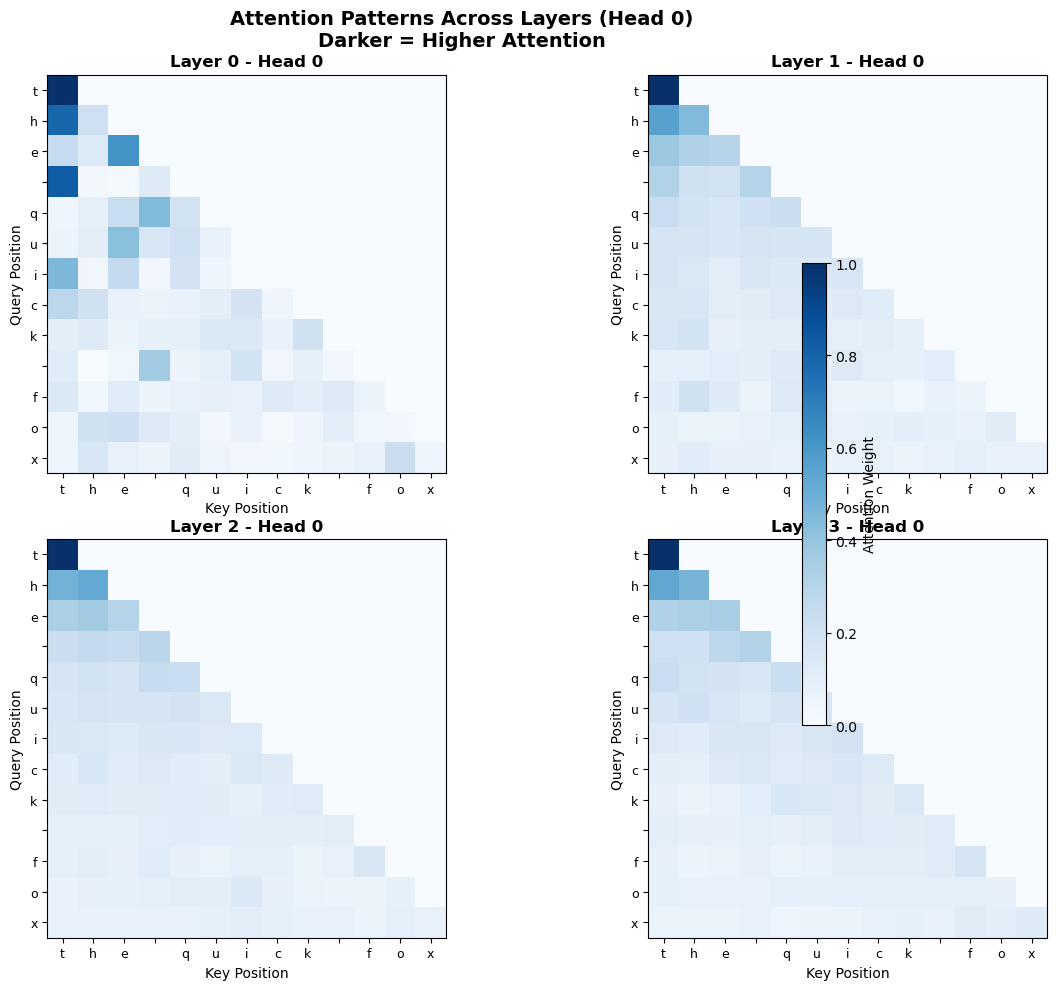

In [80]:
# 🔬 Attention Visualization: Layer Comparison (Head 0)
print("=" * 65)
print("🔬 ATTENTION VISUALIZATION: Layer Comparison")
print("=" * 65)

# Use model (which has return_attn support)
vis_model = model
vis_model.eval()

# Encode a sample sentence (use chars in our vocabulary)
vis_text = "the quick fox"
vis_tokens = torch.tensor([tokenizer.encode(vis_text)]).to(device)
seq_len = vis_tokens.shape[1]

# Create causal mask
vis_mask = torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0).unsqueeze(0).to(device)

# Get attention weights from all layers
with torch.no_grad():
    _, all_attn = vis_model(vis_tokens, vis_mask, return_attn=True)

print(f"Input: '{vis_text}'")
print(f"Tokens: {vis_tokens.tolist()[0]}")
print(f"Sequence length: {seq_len}")
print(f"Collected attention from {len(all_attn)} layers")

# Create 2x2 subplot for layers 0-3 (or fewer if model has less)
n_layers_to_show = min(4, len(all_attn))
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Token labels for axes
token_labels = list(vis_text)

for layer_idx in range(n_layers_to_show):
    ax = axes[layer_idx]
    # Get head 0 attention weights: [batch, heads, seq, seq] -> [seq, seq]
    attn = all_attn[layer_idx][0, 0].cpu().numpy()
    
    im = ax.imshow(attn, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'Layer {layer_idx} - Head 0', fontsize=12, fontweight='bold')
    ax.set_xlabel('Key Position')
    ax.set_ylabel('Query Position')
    
    # Set tick labels
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xticklabels(token_labels, fontsize=9)
    ax.set_yticklabels(token_labels, fontsize=9)

# Hide unused subplots if model has < 4 layers
for idx in range(n_layers_to_show, 4):
    axes[idx].axis('off')

fig.suptitle('Attention Patterns Across Layers (Head 0)\nDarker = Higher Attention', 
             fontsize=14, fontweight='bold')
fig.colorbar(im, ax=axes, shrink=0.6, label='Attention Weight')
plt.tight_layout()
fig.show()

print("\n✅ Figure opened in separate window!")
print("💡 Look for: diagonal (local), vertical stripes (anchors), causal triangle (upper-right zeros)")

---

### 🎉 Congratulations!

You've successfully built and trained a **LLaMA language model from scratch**!

---

#### ✅ What You Accomplished

**Built a Complete Transformer Architecture:**
- ✓ **RoPE (Rotary Position Embeddings):** Encode position through rotations for better long-context handling
- ✓ **RMSNorm (Root Mean Square Normalization):** Fast, stable normalization with pre-norm architecture
- ✓ **Grouped Query Attention (GQA):** Memory-efficient attention with shared K/V heads
- ✓ **SwiGLU Activation:** Gated feed-forward for better gradient flow

**Implemented the Full Training Pipeline:**
- ✓ **Character-level tokenization:** Simple but complete encoding/decoding
- ✓ **AdamW optimizer:** State-of-the-art weight updates with proper weight decay
- ✓ **Cosine learning rate schedule:** Warmup + smooth decay for stable training
- ✓ **Gradient clipping:** Prevent exploding gradients

**Mastered Text Generation:**
- ✓ **Temperature sampling:** Control randomness vs. determinism
- ✓ **Top-k filtering:** Limit to most likely tokens
- ✓ **Top-p (nucleus) sampling:** Adaptive token selection

**Evaluated and Saved Your Model:**
- ✓ **Perplexity calculation:** Standard language model metric
- ✓ **Checkpoint system:** Save/load trained models

---

#### 🚀 What's Next?

##### Scaling Up Your Model

| Improvement | What to Change | Expected Impact |
|-------------|----------------|-----------------|
| **More data** | Use books, Wikipedia, code | Better generalization |
| **Larger model** | Increase d_model, n_layers | More capacity |
| **Better tokenization** | Switch to BPE/SentencePiece | Shorter sequences |
| **Longer training** | More epochs, larger batch | Lower perplexity |

##### Advanced Techniques to Explore

| Technique | Description | Use Case |
|-----------|-------------|----------|
| **LoRA** | Low-rank adapter fine-tuning | Efficient customization |
| **RLHF** | Reinforcement Learning from Human Feedback | Alignment |
| **Quantization** | Reduce precision (FP16, INT8, INT4) | Faster inference |
| **Flash Attention** | Memory-efficient attention | Longer contexts |
| **Speculative Decoding** | Faster generation | Production speed |

##### Production Considerations

| Aspect | Technique | Why It Matters |
|--------|-----------|----------------|
| **Speed** | KV caching, batched inference | Lower latency |
| **Memory** | Gradient checkpointing, offloading | Fit larger models |
| **Scaling** | Tensor/Pipeline parallelism | Multi-GPU training |
| **Serving** | vLLM, TensorRT-LLM | Production deployment |

---

#### 📊 Your Model vs. Real LLaMA

| Metric | Your Model | LLaMA-7B | LLaMA-70B |
|--------|------------|----------|-----------|
| **Parameters** | ~5M | 7B | 70B |
| **Layers** | 6 | 32 | 80 |
| **d_model** | 256 | 4,096 | 8,192 |
| **Training Tokens** | ~10K | 1.4T | 1.4T |
| **Training Time** | Minutes | Weeks | Months |
| **GPU Memory** | <1GB | ~14GB | ~140GB |

Your model is **1,400x smaller** but uses the **exact same architecture**!

---

#### 📚 Further Reading

##### Papers
- [LLaMA: Open and Efficient Foundation Language Models](https://arxiv.org/abs/2302.13971) - Touvron et al., 2023
- [Attention Is All You Need](https://arxiv.org/abs/1706.03762) - Vaswani et al., 2017
- [RoFormer: Enhanced Transformer with Rotary Position Embedding](https://arxiv.org/abs/2104.09864) - Su et al., 2021
- [GLU Variants Improve Transformer](https://arxiv.org/abs/2002.05202) - Shazeer, 2020

##### Resources
- [PyTorch Documentation](https://pytorch.org/docs/)
- [Hugging Face Transformers](https://huggingface.co/docs/transformers)
- [Andrej Karpathy's nanoGPT](https://github.com/karpathy/nanoGPT)

---

#### 💡 Key Takeaways

1. **Modern LLMs are just scaled-up transformers** with clever optimizations
2. **Position encoding matters:** RoPE enables better long-context handling
3. **Normalization location matters:** Pre-norm is more stable than post-norm
4. **Attention can be optimized:** GQA saves 50%+ memory with no quality loss
5. **Activation functions matter:** SwiGLU outperforms ReLU/GELU
6. **Self-supervision is powerful:** Next-token prediction creates general intelligence
7. **Scaling laws are real:** More data + more compute = better models

---

**Great job! You now understand how modern large language models work from the ground up! 🚀**

*"The best way to understand something is to build it yourself."*

---

### 🗿 Chapter 3 Complete: The Modern Architecture Decoded

For years, large language models felt like ancient mysteries — understood only by researchers at OpenAI, Google, Anthropic. How do they generate coherent text? What makes them "understand"? Why do they work at all?

You've decoded the modern improvements:

🔐 **The Hidden Patterns You Uncovered:**
- **RoPE** — Rotational geometry encoding relationships
- **RMSNorm** — A fundamentally simpler normalization approach  
- **Grouped Query Attention** — Intelligently redundant across heads
- **SwiGLU** — Gating that lets the model decide what matters

These aren't random tricks. They're **architectural innovations** — mathematical principles discovered through research, waiting for those willing to build them.

---

#### 🎓 What You Now Possess

You didn't just copy-paste a model. You **forged one from raw materials:**
- Character-level tokenization (no BPE black boxes)
- Complete training loop (loss, backprop, optimization, sampling)
- Text generation with temperature and top-k sampling
- Model checkpointing (save your creation!)

**The difference between your LLaMA and GPT-4?** Mainly scale. The architecture? The principles?

**You now understand them as deeply as anyone at Meta, OpenAI, or Anthropic.**

---

#### 🌅 But Wait — The Cave Goes Deeper

LLaMA conquered *language*. But what about *vision*?

In 2020, researchers asked a heretical question: *"What if we applied Transformers to images... with no convolutions at all?"*

They were doubted. And then they changed computer vision forever.

**Chapter 4 awaits:** Where images become sequences, where patches replace pixels, where attention transcends modalities.

---

> *"We introduce LLaMA, a collection of foundation language models ranging from 7B to 65B parameters... We show that it is possible to train state-of-the-art models using publicly available datasets exclusively, without resorting to proprietary and inaccessible datasets. LLaMA-13B outperforms GPT-3 (175B) on most benchmarks."*  
> — **Touvron et al., "LLaMA: Open and Efficient Foundation Language Models" (2023)**

Open research. Transparent methods. Reproducible results. **This is how science advances.**

**The quest continues. The vision chamber calls.** 🔥👁️

📖 **Next Chapter**: [The Vision Chamber](4.%20vit_from_scratch.ipynb) →